# ALeRCE check new light curve classifiers, microlensing events

```Author: Alejandra Muñoz Arancibia, modifications: Kay Medina. Last updated: 20260626```

ALeRCE starter notebook for microlensing event science using the ALeRCE python client and the ALeRCE Table Access Protocol (TAP) service.

For more information about the ALeRCE broker, please visit https://science.alerce.online/, or read our publications:
* The Automatic Learning for the Rapid Classification of Events (ALeRCE) Alert Broker, [Förster et al. 2021, AJ, 161, 242](https://arxiv.org/abs/2008.03303)
* Alert Classification for the ALeRCE Broker System: The Real-time Stamp Classifier, [Carrasco-Davis et al. 2021, AJ, 162, 231](https://arxiv.org/abs/2008.03309)
* Alert Classification for the ALeRCE Broker System: The Light Curve Classifier, [Sánchez-Sáez et al. 2021, AJ, 161, 141](https://arxiv.org/abs/2008.03311)

Note that the ALeRCE client can be installed with pip.

*It is highly recommended that you try this notebook in Google Colab using the following [link](https://colab.research.google.com/github/alercebroker/usecases/blob/master/notebooks/ZTF/ALeRCE_Microlensing_Starter.ipynb).*
This will avoid you from having to sort out library installation problems and focus on the contents of the tutorial. You can try installing the dependencies later in your own system. However, note that in this notebook we use ipyaladin, which does not currently work in Google Colab.

## Requirements

Basic requirements

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.time import Time
import json

The ALeRCE client

In [2]:
#!pip install alerce

In [3]:
from alerce.core import Alerce
alerce_client = Alerce()

PyVO https://pyvo.readthedocs.io/en/latest/

In [4]:
#!pip install pyvo
import pyvo

### Some settings

In [5]:
from IPython.core.display import HTML

In [6]:
pd.set_option('display.max_colwidth', 1000)
pd.set_option('display.max_columns', None)

In [7]:
plt.style.use('default')
plt.rcParams['figure.figsize'] = (6., 4.)
plt.rcParams['figure.dpi'] = 72.

### Some functions

Ancillary functions for displaying light curves and histograms

In [8]:
def ulens_model(t, u0, tE, fs, t0, mag_0):
    t = t - t0
    u = np.sqrt(u0**2 + (t / tE) ** 2)
    A = (u**2 + 2.0) / (u * np.sqrt(u**2 + 4))
    func = -2.5 * np.log10(fs * (A - 1) + 1) + mag_0
    return func

In [9]:
def ulens(times=None, params=None):
    u0 = params['ulens_u0']
    tE = params['ulens_tE']
    fs = params['ulens_fs']
    t0 = params['ulens_t0']
    mag0 = params['ulens_mag0']
    
    return ulens_model(times, u0, tE, fs, t0, mag0)

In [10]:
def magdiff2flux_uJy(df=None, col_mag=None, col_isdiffpos='isdiffpos'):
    return 10. ** (-0.4 * (df[col_mag] - 23.9)) * df[col_isdiffpos]

In [11]:
def magtot2flux_uJy(df=None, col_mag=None):
    return 10. ** (-0.4 * (df[col_mag] - 23.9))

In [12]:
def fluxerr(df=None, col_magerr=None, col_flux=None):
    return df[col_magerr].abs() * df[col_flux].abs() / 1.0857

In [13]:
def magerr(df=None, col_fluxerr=None, col_flux=None):
    return 1.0857 * df[col_fluxerr] / df[col_flux].abs()

In [14]:
def flux_epochs(df=None, col_mag=None, col_magerr=None):
    df = df.copy()
    
    df['fluxdiff_uJy'] = magdiff2flux_uJy(df=df,
                                          col_mag=col_mag)
    df['fluxerrdiff_uJy'] = fluxerr(df=df,
                                    col_magerr=col_magerr,
                                    col_flux='fluxdiff_uJy')
    
    if col_mag + '_corr' in df.columns:
        df['fluxtot_uJy'] = magtot2flux_uJy(df=df,
                                            col_mag=col_mag + '_corr')
        mask = ~df[col_magerr + '_corr_ext'].isna() & ~df[col_magerr + '_corr_ext'].isna()
        df.loc[mask, 'fluxerrtot_uJy'] = fluxerr(df=df[mask],
                                                 col_magerr=col_magerr + '_corr_ext',
                                                 col_flux='fluxtot_uJy')
        df.loc[~mask, 'fluxerrtot_uJy'] = np.nan
    
    return df

In [15]:
# From Masci+2023 sections 6.4 and 6.5
SNT = 3.
SNU = 5.

In [16]:
def flux_uJy2magupperlim(df=None, col_fluxerr=None):
    return -2.5 * np.log10(SNU * df[col_fluxerr].abs()) + 23.9

In [17]:
def flux_uJy2mag(df=None, col_flux=None):
    return -2.5 * np.log10(df[col_flux].abs()) + 23.9 # Flux in uJy

In [18]:
def plot_lc(epochs=None, use_diff=False, use_flux=False, title='',
            show_ulens=False, params_ulens=None,
            lowsnr_as_uplim=True,
            namefig=None, showfig=True):
    fids = [1, 2]#, 3]
    
    labels_ztfa = {1: 'g', 2: 'r'}
    colors_ztfa = {1: '#56E03A', 2: '#D42F4B'}
    markers_ztfa = {1: 'o', 2: 'o'}
    sizes_ztfa = {1: 30, 2: 30}
    
    labels_ztffp = {1: 'g', 2: 'r'}
    colors_ztffp = {1: 'mediumseagreen', 2: 'firebrick'}
    markers_ztffp = {1: 'o', 2: 'o'}
    sizes_ztffp = {1: 20, 2: 20}
    
    alpha_dets = 0.7
    alpha_nondets = 0.5
    alpha_forced = 0.6
    
    size_nondets = 35
    size_forced_uplim = 20

    df_dets = epochs['detections'].copy()
    df_forced = epochs['forced_photometry'].copy()
    df_nondets = epochs['non_detections'].copy()
    df_forced_uplim = pd.DataFrame()
    
    if not use_diff and 'magpsf_corr' in df_dets.columns:
        mask = (df_dets['magpsf_corr'] < 99.) \
                & (df_dets['sigmapsf_corr_ext'] < 1.)
        df_dets = df_dets[mask].copy()
        #display(df_dets)
    
    fig, ax = plt.subplots(figsize=(10, 4))
    
    col_x = 'mjd'
        
    if use_flux:
        if use_diff:
            col_y = 'fluxdiff_uJy'
            col_yerr = 'fluxerrdiff_uJy'
        else:
            col_y = 'fluxtot_uJy'
            col_yerr = 'fluxerrtot_uJy'
    else:
        if use_diff:
            col_y = 'magpsf'
            col_yerr = 'sigmapsf'
        else:
            col_y = 'magpsf_corr'
            col_yerr = 'sigmapsf_corr_ext'
    
    for fid in fids:
        mask = df_dets['fid'] == fid
        if len(df_dets[col_y][mask].notna()) > 0:
            ax.errorbar(df_dets[col_x][mask],
                        df_dets[col_y][mask],
                        yerr=df_dets[col_yerr][mask],
                        alpha=alpha_dets, c=colors_ztfa[fid],
                        linestyle='None')
            ax.scatter(df_dets[col_x][mask],
                       df_dets[col_y][mask],
                       alpha=alpha_dets,
                       s=sizes_ztfa[fid],
                       c=colors_ztfa[fid],
                       marker=markers_ztfa[fid],
                       label='%s (detection)' % labels_ztfa[fid],
                       linestyle='None')
    
    if len(df_nondets) > 0 and use_diff and not use_flux:
        for fid in fids:
            mask = df_nondets['fid'] == fid
            if len(df_nondets[mask]) > 0:
                ax.scatter(df_nondets[col_x][mask],
                           df_nondets['diffmaglim'][mask],
                           alpha=alpha_nondets,
                           s=size_nondets,
                           c=colors_ztfa[fid],
                           marker='v',
                           label='%s (non-detection)' % labels_ztfa[fid],
                           linestyle='None')
    
    if len(df_forced) > 0:
        if not use_diff and 'mag_corr' not in df_forced.columns:
            pass
        
        if use_flux:
            if use_diff:
                col_y = 'fluxdiff_uJy'
                col_yerr = 'fluxerrdiff_uJy'
            else:
                col_y = 'fluxtot_uJy'
                col_yerr = 'fluxerrtot_uJy'
        else:
            if use_diff:
                col_y = 'mag'
                col_yerr = 'e_mag'

                if lowsnr_as_uplim:
                    mask_snt = df_forced['fluxdiff_uJy'] \
                               / df_forced['fluxerrdiff_uJy'] > SNT
                
                col_fluxerr = 'fluxerrdiff_uJy'
            else:
                col_y = 'mag_corr'
                col_yerr = 'e_mag_corr_ext'

                if lowsnr_as_uplim:
                    mask_snt = df_forced['fluxtot_uJy'] \
                               / df_forced['fluxerrtot_uJy'] > SNT
                
                col_fluxerr = 'fluxerrtot_uJy'

            if lowsnr_as_uplim:
                df_forced_uplim = df_forced[~mask_snt].copy()
                df_forced_uplim[col_y + '_upperlimit'] = flux_uJy2magupperlim(df=df_forced_uplim,
                                                                              col_fluxerr=col_fluxerr)
                
                df_forced = df_forced[mask_snt].copy()
        
        for fid in fids:
            mask = df_forced['fid'] == fid
            if len(df_forced[col_y][mask].notna()) > 0:
                ax.errorbar(df_forced[col_x][mask],
                            df_forced[col_y][mask],
                            yerr=df_forced[col_yerr][mask],
                            alpha=alpha_forced, c=colors_ztffp[fid],
                            linestyle='None')
                ax.scatter(df_forced[col_x][mask],
                           df_forced[col_y][mask],
                           alpha=alpha_forced,
                           s=sizes_ztffp[fid],
                           c='none',
                           edgecolor=colors_ztffp[fid],
                           marker=markers_ztffp[fid],
                           label='%s (forced)' % labels_ztffp[fid],
                           linestyle='None')
            
        if not use_flux and len(df_forced_uplim) > 0:
            for fid in fids:
                mask = df_forced_uplim['fid'] == fid
                if len(df_forced_uplim[mask]) > 0:
                    ax.scatter(df_forced_uplim[col_x][mask],
                               df_forced_uplim[col_y + '_upperlimit'][mask],
                               alpha=alpha_forced,
                               s=size_forced_uplim,
                               c='none',
                               edgecolor=colors_ztffp[fid],
                               marker='v',
                               label='%s (forced, upper limit)' % labels_ztffp[fid],
                               linestyle='None')
    
    ax.set_xlabel('MJD')

    ulens_names = ['u0', 'tE', 'fs', 't0', 'mag0']
    ulens_names = ['ulens_' + x for x in ulens_names]
    
    if show_ulens and params_ulens is not None:
        cols = ['mjd', 'fid', 'magpsf_corr', 'sigmapsf_corr_ext']
        
        if len(df_forced) == 0:
            df_epochs = df_dets[cols].copy()
        else:
            df_forced.rename(columns={'mag_corr': 'magpsf_corr',
                                      'e_mag_corr_ext': 'sigmapsf_corr_ext'},
                             inplace=True)
            df_epochs = pd.concat([df_dets[cols], df_forced[cols]], axis=0)
        
        df_epochs.sort_values(by=['mjd'], inplace=True)
        
        mask = df_epochs['magpsf_corr'].notna() \
               & (df_epochs['sigmapsf_corr_ext'] < 1.)
        minmjd = df_epochs['mjd'][mask].min()
        
        for fid in [1, 2]:
            mask = df_epochs['fid'] == fid
            mask2 = mask & df_epochs['magpsf_corr'].notna() \
                    & (df_epochs['sigmapsf_corr_ext'] < 1.)
            if len(df_epochs[mask]) > 0:
                mjd = df_epochs['mjd'][mask].copy()
                params = dict()

                for key in ulens_names:
                    if key + '_' + str(fid) in params_ulens.keys():
                        params[key] = params_ulens[key + '_' + str(fid)]
                
                mag = pd.DataFrame(ulens(mjd - minmjd, params=params))
                mag.rename(columns={'mjd': 'magpsf_corr'}, inplace=True)
                
                if use_flux:
                    y = magtot2flux_uJy(mag, col_mag='magpsf_corr')
                    
                    ax.plot(mjd, y, c=colors_ztfa[fid], alpha=0.5,
                            label=labels_ztfa[fid] + ' (ulens)')
                else:
                    ax.plot(mjd, mag['magpsf_corr'], c=colors_ztfa[fid], alpha=0.5,
                            label=labels_ztfa[fid] + ' (ulens)')
    
    title_aux = title[:]
    
    if show_ulens and params_ulens is not None:
        title_aux += ' (ulens: chi_g=%.2e' % params_ulens['ulens_chi_1'] \
                     + ', chi_r=%.2e' % params_ulens['ulens_chi_2'] + ')'
    
    ax.set_title(title_aux)
    
    if use_flux:
        if use_diff:
            ax.set_ylabel('Difference Flux [uJy]')
        else:
            ax.set_ylabel('Total Flux [uJy]')
    else:
        if use_diff:
            ax.set_ylabel('Difference Magnitude')
            ax.set_ylim(ax.get_ylim()[::-1])
        else:
            ax.set_ylabel('Apparent Magnitude')
            ax.set_ylim(ax.get_ylim()[::-1])
    
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

    if namefig is not None:
        plt.tight_layout()
        fig.savefig(namefig)

    if not showfig:
        plt.close(fig)

In [19]:
def plot_cols_hist(df=None, cols=None, bins=None, xlims=None,
                   title=None, fontsize=None, namefig=None, showfig=True):
    alpha = 0.7
    
    if fontsize is not None:
        plt.rcParams.update({'font.size': fontsize})
    
    for col in cols:
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.hist(df[col], bins=bins, range=xlims, alpha=alpha)
        ax.set_xlabel(col)
        ax.set_ylabel('Frequency')
        ax.set_yscale('log')
        ax.set_title(title)
        
        if namefig is not None:
            plt.tight_layout()
            fig.savefig(namefig)
    
    if fontsize is not None:
        plt.rcParams.update({'font.size': 12})
    
    if not showfig:
        plt.close(fig)

## Query microlensing events using the ALeRCE client and the ALeRCE TAP service

### For a known microlensing event, query and display its light curve and features

First, we define manually the oid that we want to explore

In [20]:
#oid = 'ZTF25aajjjlb'
oid = 'ZTF25aanzxdg'

Create a link to the ALeRCE Explorer for this object. The following function accepts lists of objects too (it works up to a maximum of 200 objects)

In [21]:
def print_link_ztf(index=None, classifier='stamp_classifier'):
    if len(index) == 1:
        expr = 'https://alerce.online/object/' + index[0]
    else:
        expr1 = 'https://alerce.online/?oid='
        expr2 = '&oid='.join(list(index))
        expr3 = '&selectedClassifier=' + classifier + '&page=1'
        expr = expr1 + expr2 + expr3
    
    display(HTML("<a href='%s' target=\"_blank\"> %s <a>" % (expr, expr)))

In [22]:
print_link_ztf(index=[oid])

We define a function to query the object light curve using the ALeRCE client

In [23]:
def find_epochs(oid=None,
                names=['detections',
                       'forced_photometry',
                       'non_detections']):
    df_dets = pd.DataFrame()
    df_forced = pd.DataFrame()
    df_nondets = pd.DataFrame()
    
    if 'detections' in names:
        df_dets = alerce_client.query_detections(oid, format='pandas')
        df_dets['oid'] = oid
        df_dets.set_index('oid', inplace=True)
        df_dets.sort_values(by='mjd', inplace=True)
        df_dets = flux_epochs(df_dets, col_mag='magpsf', col_magerr='sigmapsf')

    if 'forced_photometry' in names:
        df_forced = alerce_client.query_forced_photometry(oid, format='pandas')
        if len(df_forced) > 0:
            df_forced.set_index('oid', inplace=True)
            df_dets.sort_values(by='mjd', inplace=True)
            df_forced = flux_epochs(df_forced, col_mag='mag', col_magerr='e_mag')

    if 'non_detections' in names:
        df_nondets = alerce_client.query_non_detections(oid, format='pandas')
        if len(df_nondets) > 0:
            df_nondets['oid'] = oid
            df_nondets.set_index('oid', inplace=True)
            df_nondets.sort_values(by='mjd', inplace=True)

    epochs = {'detections': df_dets,
              'forced_photometry': df_forced,
              'non_detections': df_nondets}

    return epochs

In [24]:
epochs = find_epochs(oid=oid,
                     names=['detections',
                            'forced_photometry'])#,
                            #'non_detections'])

We display pandas dataframes for the object detections and forced photometry epochs

In [25]:
for key in epochs.keys():
    print(key)
    display(epochs[key])

detections


,tid,mjd,candid,fid,pid,diffmaglim,isdiffpos,nid,distnr,magpsf,magpsf_corr,magap,sigmapsf,sigmapsf_corr,sigmapsf_corr_ext,sigmagap,ra,dec,rb,rbversion,drb,magapbig,sigmagapbig,rfid,has_stamp,corrected,dubious,step_id_corr,phase,parent_candid,fluxdiff_uJy,fluxerrdiff_uJy,fluxtot_uJy,fluxerrtot_uJy
oid,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ZTF25aanzxdg,ztf,60789.417847,3035417845115015153,2,3035417845115,20.066702,1,3035,0.168478,18.796211,16.880098,18.7066,0.124075,0.013288,0.021244,0.1180,265.809075,-14.942089,0.631429,t17_f5_c3,0.990314,18.5487,0.1285,331120251.0,True,True,False,26.0.1,0.0,NaN,110.031137,12.574439,642.629710,12.574433
ZTF25aanzxdg,ztf,60789.417847,3035417845115025153,2,3035417845115,20.066700,1,3035,0.168478,18.796200,16.880096,18.7066,0.124075,0.013288,0.021244,0.1180,265.809075,-14.942089,0.631429,t17_f5_c3,NaN,18.5487,0.1285,NaN,False,True,False,27.5.6,0.0,3.063394e+18,110.032252,12.574608,642.630894,12.574609
ZTF25aanzxdg,ztf,60804.397558,3050397555115015155,2,3050397555115,19.317688,1,3050,0.089626,18.561441,16.836126,18.6750,0.138551,0.023375,0.028280,0.1909,265.809125,-14.942123,0.615714,t17_f5_c3,0.996924,18.7795,0.2685,331120251.0,True,True,False,27.5.6,0.0,NaN,136.591477,17.430996,669.190243,17.430991
ZTF25aanzxdg,ztf,60817.347431,3063347435115015045,1,3063347435115,20.444008,1,3063,0.142355,19.489204,17.860811,19.3713,0.149306,0.025892,0.033321,0.1535,265.809094,-14.942150,0.761429,t17_f5_c3,0.999994,19.4736,0.2131,331120151.0,True,True,False,27.5.6,0.0,NaN,58.119036,7.992563,260.420759,7.992556
ZTF25aanzxdg,ztf,60817.393982,3063393985115015026,2,3063393985115,20.156683,1,3063,0.053193,18.561686,16.836176,18.6350,0.086047,0.007414,0.017560,0.1093,265.809093,-14.942116,0.768571,t17_f5_c3,1.000000,18.6767,0.1437,331120251.0,True,True,False,27.5.6,0.0,NaN,136.560658,10.823065,669.159426,10.823068
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZTF25aanzxdg,ztf,61183.376655,3429376655115010008,3,3429376655115,19.774628,-1,3429,0.120750,16.397505,16.389660,16.5338,0.035882,100.000000,0.035624,0.0250,265.809105,-14.942160,0.774286,t17_f5_c3,0.999962,16.5628,0.0318,331120351.0,True,True,False,27.5.7a32.dev1,0.0,NaN,-1002.300622,33.125652,1009.568985,33.125626
ZTF25aanzxdg,ztf,61184.392488,3430392485115010013,3,3430392485115,19.476248,-1,3430,0.090143,16.297468,16.499022,16.3710,0.041372,0.011407,0.049811,0.0264,265.809105,-14.942153,0.814286,t17_f5_c3,0.999999,16.4006,0.0340,331120351.0,True,True,False,27.5.7a32.dev1,0.0,NaN,-1099.038231,41.880402,912.832723,41.880395
ZTF25aanzxdg,ztf,61184.392488,3430392485115020013,3,3430392485115,19.476200,-1,3430,0.090143,16.297500,16.498983,16.3710,0.041372,0.011400,0.049808,0.0264,265.809105,-14.942153,0.814286,t17_f5_c3,NaN,16.4006,0.0340,NaN,False,True,False,27.5.7a32.dev1,0.0,3.451295e+18,-1099.005839,41.879036,912.865512,41.879011


forced_photometry


,candid,tid,pid,mjd,fid,ra,e_ra,dec,e_dec,mag,e_mag,mag_corr,e_mag_corr,e_mag_corr_ext,isdiffpos,corrected,dubious,parent_candid,has_stamp,rcid,magzpscirms,distnr,rfid,clrcoeff,ranr,sciinpseeing,clrcounc,decnr,scibckgnd,exptime,magnr,scisigpix,adpctdif1,sigmagnr,magzpsci,adpctdif2,chinr,diffmaglim,programid,sharpnr,field,magzpsciunc,procstatus,fluxdiff_uJy,fluxerrdiff_uJy,fluxtot_uJy,fluxerrtot_uJy
oid,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ZTF25aanzxdg,ZTF25aanzxdg3130205995115,ztf,3130205995115,60884.205995,1,265.809107,None,-14.942167,None,17.549374,0.017864,17.050597,0.005331,0.011284,1,True,False,3130206945115015031,False,51,0.029452,0.214827,331120151,-0.044347,265.809082,2.4255,0.000025,-14.942110,566.471985,30.0,18.135,12.800400,0.134998,0.027,26.263500,0.146353,0.762,20.128000,1,-0.042,331,0.000020,0,346.936945,5.708337,549.238820,5.708337
ZTF25aanzxdg,ZTF25aanzxdg3060375265115,ztf,3060375265115,60814.375266,2,265.809107,None,-14.942190,None,18.414255,0.068815,16.804419,0.002250,0.015622,1,True,False,3089273805115015055,False,51,0.030443,0.219275,331120251,0.105844,265.809113,3.1633,0.000027,-14.942129,202.949997,30.0,17.084,27.516701,0.221605,0.020,26.170900,0.221924,0.268,19.141300,1,-0.007,331,0.000022,0,156.422039,9.914516,689.020794,9.914516
ZTF25aanzxdg,ZTF25aanzxdg3050397555115,ztf,3050397555115,60804.397558,2,265.809062,None,-14.942135,None,18.578413,0.076720,16.839569,100.000000,0.015466,1,True,False,3080353005115015032,False,51,0.025290,0.134501,331120251,0.100299,265.809113,2.7706,0.000018,-14.942129,216.852997,30.0,17.084,27.839899,0.186658,0.020,26.232401,0.199617,0.268,19.317699,1,-0.007,331,0.000015,0,134.472908,9.502390,667.071662,9.502390
ZTF25aanzxdg,ZTF25aanzxdg3035410335115,ztf,3035410335115,60789.410336,1,265.809075,None,-14.942089,None,20.111021,0.187658,17.971958,0.012033,0.026166,1,True,False,3035417845115015153,False,51,0.035195,0.090280,331120151,-0.034522,265.809082,3.2164,0.000035,-14.942110,521.114014,30.0,18.135,11.560000,0.190430,0.027,26.149200,0.206519,0.762,19.911900,1,-0.042,331,0.000029,0,32.778689,5.665636,235.080564,5.665636
ZTF25aanzxdg,ZTF25aanzxdg3018455755115,ztf,3018455755115,60772.455752,1,265.809075,None,-14.942089,None,20.470102,0.267852,18.015449,0.013966,0.027928,1,True,False,3035417845115015153,False,51,0.030762,0.090280,331120151,-0.031285,265.809082,2.4317,0.000027,-14.942110,512.721008,30.0,18.135,12.940400,0.110581,0.027,26.121799,0.123863,0.762,19.848499,1,-0.042,331,0.000022,0,23.548274,5.809561,225.850149,5.809561
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZTF25aanzxdg,ZTF25aanzxdg3442453445115,ztf,3442453445115,61196.453449,2,265.809102,None,-14.942150,None,19.345522,0.135429,16.956540,100.000000,0.015001,1,True,False,3451294905115010006,False,51,0.026664,0.074877,331120251,0.075402,265.809113,2.0183,0.000021,-14.942129,195.953995,30.0,17.084,24.408001,0.145893,0.020,26.223600,0.143357,0.268,19.487900,1,-0.007,331,0.000017,0,66.342408,8.275474,598.941162,8.275474
ZTF25aanzxdg,ZTF25aanzxdg3442357235115,ztf,3442357235115,61196.357234,3,265.809102,None,-14.942150,None,16.481012,0.014139,16.312657,100.000000,0.012108,-1,True,False,3451294905115010006,False,51,0.029397,0.081379,331120351,0.189114,265.809113,2.2331,0.000089,-14.942127,228.824005,30.0,15.641,25.344101,0.158478,0.022,25.583700,0.174303,0.443,19.089500,1,-0.031,331,0.000017,0,-928.100619,12.086884,1083.770158,12.086884
ZTF25aanzxdg,ZTF25aanzxdg3441440825115,ztf,3441440825115,61195.440822,3,265.809102,None,-14.942150,None,16.534239,0.015714,16.269062,100.000000,0.012309,-1,True,False,3451294905115010006,False,51,0.025759,0.081379,331120351,0.193153,265.809113,2.1418,0.000068,-14.942127,219.970001,30.0,15.641,20.364700,0.138104,0.022,25.563700,0.149594,0.443,19.040899,1,-0.031,331,0.000013,0,-883.699225,12.790073,1128.171552,12.790073


non_detections


""


We query all features available for this object using the ALeRCE client

In [26]:
features_all = alerce_client.query_features(oid, format='pandas')

In [27]:
features_all

,name,value,fid,version
0,Autocor_length,10.000000,2,23.12.26a85
1,Beyond1Std,0.285714,1,23.12.26a85
2,Beyond1Std,0.245902,2,23.12.26a85
3,Con,0.044118,1,23.12.26a85
4,Con,0.050847,2,23.12.26a85
...,...,...,...,...
591,n_forced_phot_band_before,4.000000,1,27.5.7a32.dev1
592,dbrightness_first_det_band,25.340325,1,27.5.7a32.dev1
593,dbrightness_forced_phot_band,32.847697,1,27.5.7a32.dev1
594,max_brightness_before_band,32.778689,1,27.5.7a32.dev1


In [28]:
pd.unique(features_all['version'])

array(['23.12.26a85', '27.5.6', '27.5.7a32.dev1'], dtype=object)

We select only the latest version (as it is the one used by the ALeRCE light curve classifiers that include forced photometry data)

In [29]:
#feature_version = '27.5.6' # Latest version by June 9 2025, used in SQL queries

# Latest version by June 26 2026 in the ZTF legacy on-premise database
# Since Oct 21 2025
feature_version = '27.5.7a32.dev1'

In [30]:
mask = features_all['version'] == feature_version
features = features_all[mask].copy()

In [31]:
features

,name,value,fid,version
386,g-r_mean,0.759997,12,27.5.7a32.dev1
387,g-r_max,1.061791,12,27.5.7a32.dev1
388,g-r_mean_corr,0.914623,12,27.5.7a32.dev1
389,g-r_max_corr,1.060284,12,27.5.7a32.dev1
390,W1-W2,NaN,0,27.5.7a32.dev1
...,...,...,...,...
591,n_forced_phot_band_before,4.000000,1,27.5.7a32.dev1
592,dbrightness_first_det_band,25.340325,1,27.5.7a32.dev1
593,dbrightness_forced_phot_band,32.847697,1,27.5.7a32.dev1
594,max_brightness_before_band,32.778689,1,27.5.7a32.dev1


We pivot this dataframe to make the features appear as columns

In [32]:
df_features = features.copy()
df_features['oid'] = oid
df_features['fname'] = df_features['name'] + '_' + df_features['fid'].astype(str)
df_features = df_features.pivot_table(index='oid', columns='fname', values='value', dropna=False)

In [33]:
df_features

fname,Amplitude_1,Amplitude_2,AndersonDarling_1,AndersonDarling_2,Autocor_length_1,Autocor_length_2,Beyond1Std_1,Beyond1Std_2,Con_1,Con_2,Coordinate_x_0,Coordinate_y_0,Coordinate_z_0,Eta_e_1,Eta_e_2,ExcessVar_1,ExcessVar_2,GP_DRW_sigma_1,GP_DRW_sigma_2,GP_DRW_tau_1,GP_DRW_tau_2,Gskew_1,Gskew_2,Harmonics_chi_1,Harmonics_chi_2,Harmonics_mag_1_1,Harmonics_mag_1_2,Harmonics_mag_2_1,Harmonics_mag_2_2,Harmonics_mag_3_1,Harmonics_mag_3_2,Harmonics_mag_4_1,Harmonics_mag_4_2,Harmonics_mag_5_1,Harmonics_mag_5_2,Harmonics_mag_6_1,Harmonics_mag_6_2,Harmonics_mag_7_1,Harmonics_mag_7_2,Harmonics_mse_1,Harmonics_mse_2,Harmonics_phase_2_1,Harmonics_phase_2_2,Harmonics_phase_3_1,Harmonics_phase_3_2,Harmonics_phase_4_1,Harmonics_phase_4_2,Harmonics_phase_5_1,Harmonics_phase_5_2,Harmonics_phase_6_1,Harmonics_phase_6_2,Harmonics_phase_7_1,Harmonics_phase_7_2,IAR_phi_1,IAR_phi_2,LinearTrend_1,LinearTrend_2,MHPS_PN_flag_1,MHPS_PN_flag_2,MHPS_high_1,MHPS_high_2,MHPS_high_30_1,MHPS_high_30_2,MHPS_low_1,MHPS_low_2,MHPS_low_365_1,MHPS_low_365_2,MHPS_non_zero_1,MHPS_non_zero_2,MHPS_ratio_1,MHPS_ratio_2,MHPS_ratio_365_30_1,MHPS_ratio_365_30_2,MaxSlope_1,MaxSlope_2,Mean_1,Mean_2,Meanvariance_1,Meanvariance_2,MedianAbsDev_1,MedianAbsDev_2,MedianBRP_1,MedianBRP_2,Multiband_period_12,PPE_12,PairSlopeTrend_1,PairSlopeTrend_2,PercentAmplitude_1,PercentAmplitude_2,Period_band_1,Period_band_2,Power_rate_1/2_12,Power_rate_1/3_12,Power_rate_1/4_12,Power_rate_2_12,Power_rate_3_12,Power_rate_4_12,Psi_CS_1,Psi_CS_2,Psi_eta_1,Psi_eta_2,Pvar_1,Pvar_2,Q31_1,Q31_2,Rcs_1,Rcs_2,SF_ML_amplitude_1,SF_ML_amplitude_2,SF_ML_gamma_1,SF_ML_gamma_2,SPM_A_1,SPM_A_2,SPM_beta_1,SPM_beta_2,SPM_chi_1,SPM_chi_2,SPM_gamma_1,SPM_gamma_2,SPM_t0_1,SPM_t0_2,SPM_tau_fall_1,SPM_tau_fall_2,SPM_tau_rise_1,SPM_tau_rise_2,Skew_1,Skew_2,SmallKurtosis_1,SmallKurtosis_2,Std_1,Std_2,StetsonK_1,StetsonK_2,TDE_decay_1,TDE_decay_2,TDE_decay_chi_1,TDE_decay_chi_2,TDE_mag0_1,TDE_mag0_2,Timespan_0,W1-W2_0,W2-W3_0,W3-W4_0,color_variation_12,dbrightness_first_det_band_1,dbrightness_first_det_band_2,dbrightness_forced_phot_band_1,dbrightness_forced_phot_band_2,delta_period_1,delta_period_2,distpsnr1_0,fleet_a_1,fleet_a_2,fleet_chi_1,fleet_chi_2,fleet_m0_1,fleet_m0_2,fleet_t0_1,fleet_t0_2,fleet_w_1,fleet_w_2,g-W1_0,g-W2_0,g-W3_0,g-W4_0,g-r_max_12,g-r_max_corr_12,g-r_mean_12,g-r_mean_corr_12,last_brightness_before_band_1,last_brightness_before_band_2,max_brightness_after_band_1,max_brightness_after_band_2,max_brightness_before_band_1,max_brightness_before_band_2,mean_chinr_12,mean_distnr_12,mean_sharpnr_12,median_brightness_after_band_1,median_brightness_after_band_2,median_brightness_before_band_1,median_brightness_before_band_2,n_forced_phot_band_after_1,n_forced_phot_band_after_2,n_forced_phot_band_before_1,n_forced_phot_band_before_2,positive_fraction_1,positive_fraction_2,ps_g-r_0,ps_i-z_0,ps_r-i_0,r-W1_0,r-W2_0,r-W3_0,r-W4_0,sgscore1_0,sigma_distnr_12,ulens_chi_1,ulens_chi_2,ulens_fs_1,ulens_fs_2,ulens_mag0_1,ulens_mag0_2,ulens_t0_1,ulens_t0_2,ulens_tE_1,ulens_tE_2,ulens_u0_1,ulens_u0_2
oid,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ZTF25aanzxdg,0.909332,0.918094,1.0,1.0,12.0,10.0,0.285714,0.245902,0.044118,0.050847,-0.070609,-0.963603,-0.257844,0.003305,0.004276,0.00073,0.000995,135126.72046,1.064266e+06,227.541092,403.428793,-0.634176,-0.792442,19.94092,25.407424,13.157002,1.174136,10.645669,1.149578,7.84041,0.778221,4.974069,0.442057,2.448567,0.165139,1.023916,0.101581,0.231428,0.082563,0.043165,0.02662,3.272421,4.997844,0.212186,4.00167,3.421924,3.039616,0.353372,1.991172,3.599861,0.746628,0.630554,4.834948,0.995522,0.997177,-0.01738,-0.015709,0.0,0.0,0.037299,0.032587,0.887878,0.628153,24.086657,28.418509,6.118634,12.929517,75.0,82.0,645.76825,872.07251,6.891299,20.583391,74.77087,50.143656,17.125965,16.178578,0.027155,0.031592,0.191504,0

Show feature names

In [34]:
cols_features = [x for x in df_features.columns]

In [35]:
cols_features

['Amplitude_1',
 'Amplitude_2',
 'AndersonDarling_1',
 'AndersonDarling_2',
 'Autocor_length_1',
 'Autocor_length_2',
 'Beyond1Std_1',
 'Beyond1Std_2',
 'Con_1',
 'Con_2',
 'Coordinate_x_0',
 'Coordinate_y_0',
 'Coordinate_z_0',
 'Eta_e_1',
 'Eta_e_2',
 'ExcessVar_1',
 'ExcessVar_2',
 'GP_DRW_sigma_1',
 'GP_DRW_sigma_2',
 'GP_DRW_tau_1',
 'GP_DRW_tau_2',
 'Gskew_1',
 'Gskew_2',
 'Harmonics_chi_1',
 'Harmonics_chi_2',
 'Harmonics_mag_1_1',
 'Harmonics_mag_1_2',
 'Harmonics_mag_2_1',
 'Harmonics_mag_2_2',
 'Harmonics_mag_3_1',
 'Harmonics_mag_3_2',
 'Harmonics_mag_4_1',
 'Harmonics_mag_4_2',
 'Harmonics_mag_5_1',
 'Harmonics_mag_5_2',
 'Harmonics_mag_6_1',
 'Harmonics_mag_6_2',
 'Harmonics_mag_7_1',
 'Harmonics_mag_7_2',
 'Harmonics_mse_1',
 'Harmonics_mse_2',
 'Harmonics_phase_2_1',
 'Harmonics_phase_2_2',
 'Harmonics_phase_3_1',
 'Harmonics_phase_3_2',
 'Harmonics_phase_4_1',
 'Harmonics_phase_4_2',
 'Harmonics_phase_5_1',
 'Harmonics_phase_5_2',
 'Harmonics_phase_6_1',
 'Harmonics_pha

Show only feature names for the microlensing model used by ALeRCE, which is based on Khakpash et al. (2021, AJ, 161, 132)

In [36]:
cols_ulens = df_features.columns[df_features.columns.str.contains('ulens')].tolist()

In [37]:
cols_ulens

['ulens_chi_1',
 'ulens_chi_2',
 'ulens_fs_1',
 'ulens_fs_2',
 'ulens_mag0_1',
 'ulens_mag0_2',
 'ulens_t0_1',
 'ulens_t0_2',
 'ulens_tE_1',
 'ulens_tE_2',
 'ulens_u0_1',
 'ulens_u0_2']

In [38]:
df_features[cols_ulens]

fname,ulens_chi_1,ulens_chi_2,ulens_fs_1,ulens_fs_2,ulens_mag0_1,ulens_mag0_2,ulens_t0_1,ulens_t0_2,ulens_tE_1,ulens_tE_2,ulens_u0_1,ulens_u0_2
oid,,,,,,,,,,,,
ZTF25aanzxdg,0.56768,1.317329,1.0,0.945645,18.140694,17.077342,163.160109,163.039998,100.350995,100.181419,0.133492,0.132902


We define a function that plots the light curve and microlensing model for a given object

In [39]:
def plot_lc_oid(oid=None,
                show_params=False,
                show_epochs=False,
                features=None,
                brightness_types=['difference flux',
                                  'difference magnitude',
                                  'total flux',
                                  'apparent magnitude']):
    print(oid)
    print_link_ztf(index=[oid], classifier='stamp_classifier')
    epochs = find_epochs(oid=oid,
                         names=['detections',
                                'forced_photometry'])#,
                                #'non_detections'])
    
    print(str(len(epochs['detections'])) + ' detections')
    print(str(len(epochs['forced_photometry'])) + ' forced photometry epochs')
    #print(str(len(epochs['non_detections'])) + ' non-detections')

    if features is not None:
        ulens_this = features.loc[[oid], cols_ulens].T.copy()
        ulens_this.columns = ['value']
        ulens_this = {key: val for (key, val) in zip(ulens_this.index,
                                                     ulens_this['value'])}
        if show_params:
            display(ulens_this)
    if show_epochs:
        display(epochs['detections'])
        display(epochs['forced_photometry'])
        display(epochs['non_detections'])

    name = 'apparent magnitude'
    if name in brightness_types:
        plot_lc(epochs=epochs, title=oid + ', ' + name,
                show_ulens=True, params_ulens=ulens_this)#, lowsnr_as_uplim=False)
    name = 'total flux'
    if name in brightness_types:
        plot_lc(epochs=epochs, title=oid + ', ' + name,
                show_ulens=True, params_ulens=ulens_this, use_flux=True)
    name = 'difference magnitude'
    if name in brightness_types:
        plot_lc(epochs=epochs, title=oid + ', ' + name,
                use_diff=True)#, lowsnr_as_uplim=False)
    name = 'difference flux'
    if name in brightness_types:
        plot_lc(epochs=epochs, title=oid + ', ' + name,
                use_diff=True, use_flux=True)

We plot the light curve for the object, using four different types for the brightness. Apparent magnitudes and total fluxes include the contribution of the reference object (if any)

ZTF25aanzxdg


171 detections
145 forced photometry epochs


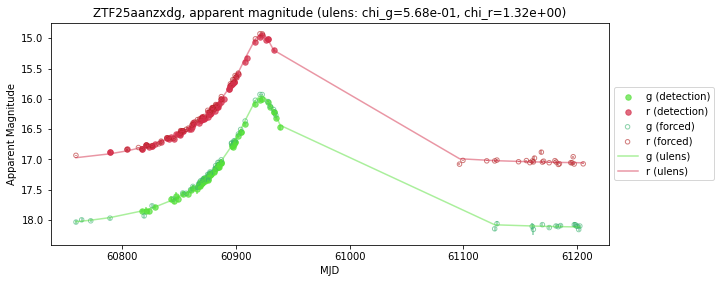

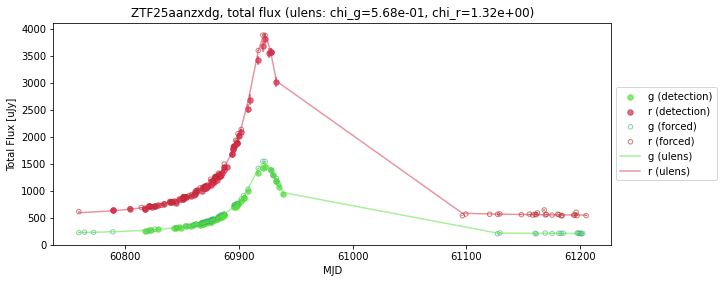

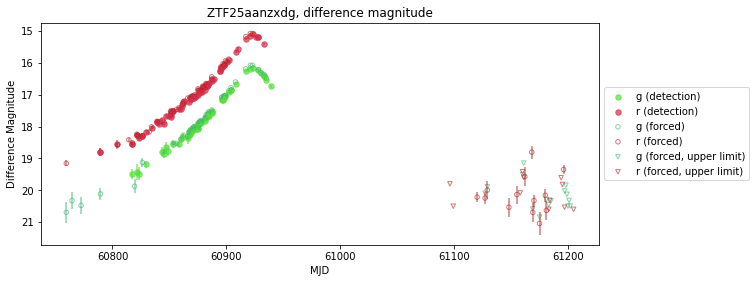

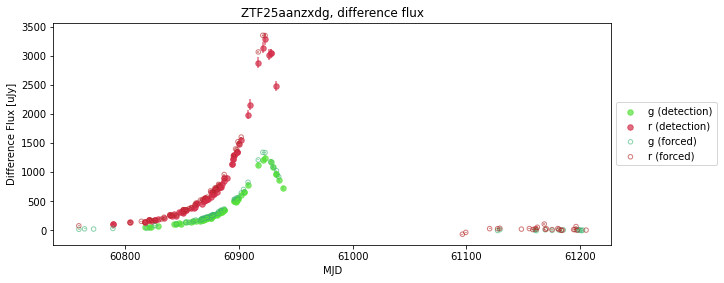

In [40]:
brightness_types = [
    'apparent magnitude',
    'total flux',
    'difference magnitude',
    'difference flux',
]

plot_lc_oid(
    oid=oid,
    features=df_features,
    brightness_types=brightness_types,
)

### New classifiers: names, versions, taxonomy

Details for the ALeRCE new light curve classifiers and features, which include ZTF forced photometry data, will be introduced in a forthcoming paper (Cabrera-Vives et al., in preparation).

In [41]:
classifier_names = [
    'lc_classifier_BHRF_forced_phot',
    'LC_classifier_ATAT_forced_phot(beta)',
]

# Latest classifier versions (probability table)
#classifier_versions = ['2.1.0', '1.1.0_beta'] # Used in SQL queries
classifier_versions = ['2.1.0', '1.0.0']

# Latest feature version (feature table), it is used for these classifiers
#feature_versions = ['27.5.6'] # Used in SQL queries
feature_versions = ['27.5.6', '27.5.7a32.dev1'] # Used in the ZTF legacy on-premise database

# Taxonomy for new classifiers
cls_sort = ['SNIa', 'SESN', 'SNII', 'SNIIn', 'SLSN', 'TDE',
            'Microlensing', 'QSO', 'AGN', 'Blazar', 'YSO', 'CV/Nova',
            'LPV', 'EA', 'EB/EW', 'Periodic-Other', 'RSCVn', 'CEP', 'RRLab', 'RRLc', 'DSCT']

### Query probabilities for lc_classifier_BHRF_forced_phot

### TAP connection setup

Instead of using a direct PostgreSQL connection, we connect to the ALeRCE ZTF legacy database using Astronomical Data Query Language ([ADQL](https://www.ivoa.net/documents/ADQL/)) queries to the ALeRCE TAP service, returning results as pandas dataframes. Database table names are prefixed with `ztf.` (e.g. `ztf.object`, `ztf.detection`, etc.).

In [42]:
TAP_URL = "https://tap.alerce.online/tap"
tap_service = pyvo.dal.TAPService(TAP_URL)

def tap_query(query, maxrec=10_000_000):
    result = tap_service.search(query, maxrec=maxrec)
    return result.to_table().to_pandas()

def tap_query_idlist(query, index, maxrec=10_000_000):
    # Upload oid (or other identifier fields) list as a TAP table.
    # IMPORTANT: call the upload column something other than "oid", as "oid" collides
    # with PostgreSQL's system column and breaks the join ("objectid" works)
    col = 'objectid'
    oid_table = Table({col: index})
    result = tap_service.search(query, uploads={'mylist': oid_table},
                                maxrec=maxrec).to_table().to_pandas()
    if col in result.columns:
        result.drop(columns=[col], inplace=True)
    return result

#### Query recent objects

New classifiers started on May 21 2025 (lc_classifier_BHRF_forced_phot) and Apr 8 2025 (LC_classifier_ATAT_forced_phot(beta)) in the ZTF legacy on-premise database. Given the 2min timeout for public users, this query to the object table is useful before querying the probability table, specially for classifiers in beta mode. Note that light curve classifiers in a beta stage lack some indices (ranking and probability) in the probability table, making some queries very slow.

In this query, we select objects that had their first ZTF detection on or after June 1 2025, and have at least 8 detections (irrespective of band).

In [43]:
firstmjd_min = Time('2025-06-01T00:00:00', format='isot', scale='utc').mjd
print(firstmjd_min)

60827.0


In [44]:
# Heavy query (~2 min)

ndet_min = 8

query = '''
SELECT
    oid, ndet, meanra, meandec,
    firstmjd, lastmjd, deltajd
FROM
    ztf.object
WHERE
    ndet >= %d
    AND firstmjd > %g
''' % (ndet_min, firstmjd_min)
#print(query)

df_recent = tap_query(query)
df_recent.set_index('oid', inplace=True)
display(df_recent)

,ndet,meanra,meandec,firstmjd,lastmjd,deltajd
oid,,,,,,
ZTF20abesrvk,35,277.184781,-13.300532,61100.525347,61217.317199,116.791852
ZTF20abbjpqo,10,288.250926,3.651562,61100.528646,61217.328032,116.799387
ZTF20abdsncz,19,273.502787,-11.405047,61123.496505,61217.317199,93.820694
ZTF20aazutub,11,287.801895,4.997084,61195.450255,61217.328032,21.877778
ZTF26aatqmyt,32,291.684525,3.994821,61150.489502,61217.328032,66.838530
...,...,...,...,...,...,...
ZTF21abinbca,14,297.958451,11.170442,61110.537361,61217.339572,106.802211
ZTF25abdmktg,21,310.478682,-12.305313,60880.360428,61217.347593,336.987164
ZTF26aahkvyz,68,272.761320,-11.140245,61094.528854,61217.317199,122.788345


#### Query ranking=1 probabilities in lc_classifier_BHRF_forced_phot for these objects

Note that objects that have less than 8 detections with rb>=0.55 will not have classifications

In [45]:
i = 0
clf_name = classifier_names[i]
clf_version = classifier_versions[i]
cl_this = 'Microlensing'

In [46]:
def query_probs_r1(chunk_size=3000, oids=None,
                   clf_name='lc_classifier_BHRF_forced_phot',
                   clf_version=None, cl='Microlensing'):
    bin_ids = np.arange(int(np.ceil(len(oids) / chunk_size)))
    print(str(len(bin_ids)) + ' chunks')

    df_probs = pd.DataFrame()
    
    for idx in bin_ids:
        print('Chunk ' + str(idx))

        index_i = idx * chunk_size
        index_f = (idx + 1) * chunk_size
        names = np.array(oids)[index_i:index_f].tolist()
        #print(names)

        query = '''
        SELECT
            oid, class_name, probability, ranking
        FROM
            ztf.probability AS p
        JOIN tap_upload.mylist AS u ON p.oid = u.objectid
        WHERE
            classifier_name = '%s'
            AND classifier_version = '%s'
            AND ranking = 1
            AND class_name = '%s'
        ''' % (clf_name, clf_version, cl)
        
        df_aux = tap_query_idlist(query, names)
        df_probs = pd.concat([df_probs, df_aux], axis=0)
        del df_aux

    return df_probs

In [47]:
print(clf_name, clf_version)

# Loop of queries
df_probs_r1_ulens = query_probs_r1(chunk_size=10000,
                                   oids=df_recent.index,
                                   clf_name=clf_name,
                                   clf_version=clf_version,
                                   cl=cl_this)
df_probs_r1_ulens.set_index('oid', inplace=True)
display(df_probs_r1_ulens)

lc_classifier_BHRF_forced_phot 2.1.0
11 chunks
Chunk 0
Chunk 1
Chunk 2
Chunk 3
Chunk 4
Chunk 5
Chunk 6
Chunk 7
Chunk 8
Chunk 9
Chunk 10


,class_name,probability,ranking
oid,,,
ZTF20aazutub,Microlensing,0.216720,1
ZTF26aatqmyt,Microlensing,0.167956,1
ZTF19adifoir,Microlensing,0.324720,1
ZTF20abbjmux,Microlensing,0.174696,1
ZTF25aaxxqjs,Microlensing,0.269916,1
...,...,...,...
ZTF26aayfxis,Microlensing,0.250976,1
ZTF26aarhcsy,Microlensing,0.171600,1
ZTF20abganmd,Microlensing,0.182000,1


In [48]:
df_probs_r1_ulens.sort_values(by='probability',
                              ascending=False,
                              inplace=True)

Show an ALeRCE Explorer link for these objects, sort by probability

In [49]:
print(clf_name, clf_version, cl_this)
print(str(len(df_probs_r1_ulens)) + ' rows')

if len(df_probs_r1_ulens) > 0:
    print_link_ztf(index=df_probs_r1_ulens.iloc[0:200].index,
               classifier='stamp_classifier')
    display(df_probs_r1_ulens)#.iloc[0:10])

lc_classifier_BHRF_forced_phot 2.1.0 Microlensing
5384 rows


,class_name,probability,ranking
oid,,,
ZTF26aawlzan,Microlensing,0.578896,1
ZTF20abmgrfz,Microlensing,0.551824,1
ZTF20aazurwo,Microlensing,0.542144,1
ZTF26abckjvu,Microlensing,0.515452,1
ZTF25aazlwgp,Microlensing,0.515424,1
...,...,...,...
ZTF25abzqogh,Microlensing,0.102272,1
ZTF24abqzrpz,Microlensing,0.102120,1
ZTF25acfqmnp,Microlensing,0.097572,1


#### Show distribution of probabilities

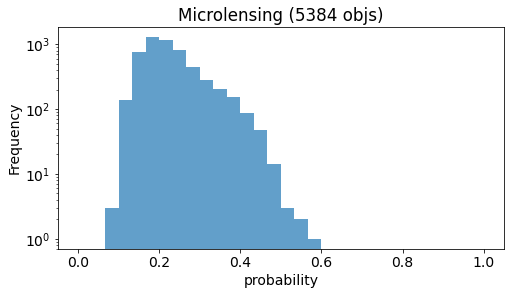

In [50]:
prop = 'probability'
title = cl_this + ' (' + str(len(df_probs_r1_ulens)) + ' objs)'
plot_cols_hist(df=df_probs_r1_ulens, cols=[prop], bins=30, xlims=[0., 1.],
               title=title, fontsize=14)

#### Query features for these objects and a given feature version

In [51]:
def query_features(chunk_size=2000, oids=None,
                   ft_versions=None):
    bin_ids = np.arange(int(np.ceil(len(oids) / chunk_size)))
    print(str(len(bin_ids)) + ' chunks')

    df_features = pd.DataFrame()
    
    for idx in bin_ids:
        print('Chunk ' + str(idx))

        index_i = idx * chunk_size
        index_f = (idx + 1) * chunk_size
        names = np.array(oids)[index_i:index_f].tolist()
        #print(names)
        
        query = '''
        SELECT
            oid, name, "value", fid, version
        FROM
            ztf.feature AS f
        JOIN tap_upload.mylist AS u ON f.oid = u.objectid
        WHERE
            version IN (%s)
        ''' % (','.join(["'%s'" % ft_version for ft_version in ft_versions]))
        #print(query)
        
        df_aux = tap_query_idlist(query, names)
        
        if len(df_aux) > 0:
            df_aux.sort_values(by=['oid', 'name', 'fid'], inplace=True)
            df_features = pd.concat([df_features, df_aux.drop_duplicates(
                subset=["oid", "name", "fid"], keep='last'
                )], axis=0)
        del df_aux

    return df_features

In [52]:
# Heavy query (~7 min)

oids_some = df_probs_r1_ulens.index

df_features_some = query_features(oids=oids_some,
                                  ft_versions=feature_versions)
df_features_some.sort_values(by=['oid', 'name', 'fid'], inplace=True)
df_features_some.set_index('oid', inplace=True)
print(str(len(df_features_some)) + ' rows')

3 chunks
Chunk 0
Chunk 1
Chunk 2
1125256 rows


In [53]:
display(df_features_some)

,name,value,fid,version
oid,,,,
ZTF17aaawmed,Amplitude,NaN,1,27.5.7a32.dev1
ZTF17aaawmed,Amplitude,0.040277,2,27.5.7a32.dev1
ZTF17aaawmed,AndersonDarling,NaN,1,27.5.7a32.dev1
ZTF17aaawmed,AndersonDarling,0.970835,2,27.5.7a32.dev1
ZTF17aaawmed,Autocor_length,NaN,1,27.5.7a32.dev1
...,...,...,...,...
ZTF26abdvfmd,ulens_t0,4.385803,2,27.5.7a32.dev1
ZTF26abdvfmd,ulens_tE,278.281438,1,27.5.7a32.dev1
ZTF26abdvfmd,ulens_tE,1547.717635,2,27.5.7a32.dev1


In [54]:
df_features = df_features_some.copy()
df_features['fname'] = df_features['name'] + '_' + df_features['fid'].astype(str)
df_features = df_features.pivot_table(index='oid', columns='fname',
                                      values='value', dropna=False)
oids_features = df_probs_r1_ulens.index.intersection(df_features.index)
df_features = df_features.loc[oids_features].copy()

In [55]:
display(df_features)

fname,Amplitude_1,Amplitude_2,AndersonDarling_1,AndersonDarling_2,Autocor_length_1,Autocor_length_2,Beyond1Std_1,Beyond1Std_2,Con_1,Con_2,Coordinate_x_0,Coordinate_y_0,Coordinate_z_0,Eta_e_1,Eta_e_2,ExcessVar_1,ExcessVar_2,GP_DRW_sigma_1,GP_DRW_sigma_2,GP_DRW_tau_1,GP_DRW_tau_2,Gskew_1,Gskew_2,Harmonics_chi_1,Harmonics_chi_2,Harmonics_mag_1_1,Harmonics_mag_1_2,Harmonics_mag_2_1,Harmonics_mag_2_2,Harmonics_mag_3_1,Harmonics_mag_3_2,Harmonics_mag_4_1,Harmonics_mag_4_2,Harmonics_mag_5_1,Harmonics_mag_5_2,Harmonics_mag_6_1,Harmonics_mag_6_2,Harmonics_mag_7_1,Harmonics_mag_7_2,Harmonics_mse_1,Harmonics_mse_2,Harmonics_phase_2_1,Harmonics_phase_2_2,Harmonics_phase_3_1,Harmonics_phase_3_2,Harmonics_phase_4_1,Harmonics_phase_4_2,Harmonics_phase_5_1,Harmonics_phase_5_2,Harmonics_phase_6_1,Harmonics_phase_6_2,Harmonics_phase_7_1,Harmonics_phase_7_2,IAR_phi_1,IAR_phi_2,LinearTrend_1,LinearTrend_2,MHPS_PN_flag_1,MHPS_PN_flag_2,MHPS_high_1,MHPS_high_2,MHPS_high_30_1,MHPS_high_30_2,MHPS_low_1,MHPS_low_2,MHPS_low_365_1,MHPS_low_365_2,MHPS_non_zero_1,MHPS_non_zero_2,MHPS_ratio_1,MHPS_ratio_2,MHPS_ratio_365_30_1,MHPS_ratio_365_30_2,MaxSlope_1,MaxSlope_2,Mean_1,Mean_2,Meanvariance_1,Meanvariance_2,MedianAbsDev_1,MedianAbsDev_2,MedianBRP_1,MedianBRP_2,Multiband_period_12,PPE_12,PairSlopeTrend_1,PairSlopeTrend_2,PercentAmplitude_1,PercentAmplitude_2,Period_band_1,Period_band_2,Power_rate_1/2_12,Power_rate_1/3_12,Power_rate_1/4_12,Power_rate_2_12,Power_rate_3_12,Power_rate_4_12,Psi_CS_1,Psi_CS_2,Psi_eta_1,Psi_eta_2,Pvar_1,Pvar_2,Q31_1,Q31_2,Rcs_1,Rcs_2,SF_ML_amplitude_1,SF_ML_amplitude_2,SF_ML_gamma_1,SF_ML_gamma_2,SPM_A_1,SPM_A_2,SPM_beta_1,SPM_beta_2,SPM_chi_1,SPM_chi_2,SPM_gamma_1,SPM_gamma_2,SPM_t0_1,SPM_t0_2,SPM_tau_fall_1,SPM_tau_fall_2,SPM_tau_rise_1,SPM_tau_rise_2,Skew_1,Skew_2,SmallKurtosis_1,SmallKurtosis_2,Std_1,Std_2,StetsonK_1,StetsonK_2,TDE_decay_1,TDE_decay_2,TDE_decay_chi_1,TDE_decay_chi_2,TDE_mag0_1,TDE_mag0_2,Timespan_0,W1-W2_0,W2-W3_0,W3-W4_0,color_variation_12,dbrightness_first_det_band_1,dbrightness_first_det_band_2,dbrightness_forced_phot_band_1,dbrightness_forced_phot_band_2,delta_period_1,delta_period_2,distpsnr1_0,fleet_a_1,fleet_a_2,fleet_chi_1,fleet_chi_2,fleet_m0_1,fleet_m0_2,fleet_t0_1,fleet_t0_2,fleet_w_1,fleet_w_2,g-W1_0,g-W2_0,g-W3_0,g-W4_0,g-r_max_12,g-r_max_corr_12,g-r_mean_12,g-r_mean_corr_12,last_brightness_before_band_1,last_brightness_before_band_2,max_brightness_after_band_1,max_brightness_after_band_2,max_brightness_before_band_1,max_brightness_before_band_2,mean_chinr_12,mean_distnr_12,mean_sharpnr_12,median_brightness_after_band_1,median_brightness_after_band_2,median_brightness_before_band_1,median_brightness_before_band_2,n_forced_phot_band_after_1,n_forced_phot_band_after_2,n_forced_phot_band_before_1,n_forced_phot_band_before_2,positive_fraction_1,positive_fraction_2,ps_g-r_0,ps_i-z_0,ps_r-i_0,r-W1_0,r-W2_0,r-W3_0,r-W4_0,sgscore1_0,sigma_distnr_12,ulens_chi_1,ulens_chi_2,ulens_fs_1,ulens_fs_2,ulens_mag0_1,ulens_mag0_2,ulens_t0_1,ulens_t0_2,ulens_tE_1,ulens_tE_2,ulens_u0_1,ulens_u0_2
oid,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ZTF26aawlzan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.062841,-0.952101,-0.299257,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.572236,0.324616,0.369189,0.011486,0.167468,0.014606,0.128587,0.013694,0.201060,0.015809,0.192557,0.014513,0.211277,0.008523,0.086127,0.014073,0.019273,0.001287,2.862971,3.859646,4.909889,2.637283,1.526115,0.718380,4.869439,2.664383,1.768511,2.864605,5.365200,0.659511,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.056643,0.001236,NaN,NaN,NaN,NaN,0.056643,0.084138,0.090953,0.090953,0.090953,0.081834,0.235830,0.385489,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.009747,0.057312,0.073604,0.151311,0.841129,0.748

#### Explore the distributions of some features

In [56]:
cols_ulens

['ulens_chi_1',
 'ulens_chi_2',
 'ulens_fs_1',
 'ulens_fs_2',
 'ulens_mag0_1',
 'ulens_mag0_2',
 'ulens_t0_1',
 'ulens_t0_2',
 'ulens_tE_1',
 'ulens_tE_2',
 'ulens_u0_1',
 'ulens_u0_2']

In [57]:
display(df_features[cols_ulens].describe())

fname,ulens_chi_1,ulens_chi_2,ulens_fs_1,ulens_fs_2,ulens_mag0_1,ulens_mag0_2,ulens_t0_1,ulens_t0_2,ulens_tE_1,ulens_tE_2,ulens_u0_1,ulens_u0_2
count,3716.000000,5027.000000,3.734000e+03,5.047000e+03,3734.000000,5047.000000,3734.000000,5047.000000,3.734000e+03,5047.000000,3.734000e+03,5.047000e+03
mean,1.342118,2.252268,7.176561e-01,7.405445e-01,18.584402,17.770744,93.176266,90.132084,5.111734e+02,756.558688,6.379356e+00,4.961787e+00
std,2.581455,4.554424,4.146980e-01,4.104800e-01,1.639686,1.982019,130.201558,134.318950,1.818091e+03,2997.313541,4.178655e+01,2.880074e+01
min,0.021866,0.000079,7.961746e-14,2.029610e-19,13.381497,12.363888,-722.025350,-1077.526052,9.205590e-07,0.000020,4.940656e-324,4.940656e-324
25%,0.566483,0.672283,3.113103e-01,4.346578e-01,17.356087,16.286206,23.914771,19.656651,1.770156e+00,2.795229,3.909165e-03,5.436851e-03
50%,0.848742,1.127363,9.999973e-01,9.999983e-01,18.499090,17.530020,58.186141,46.951241,1.002485e+01,14.008660,3.770037e-01,4.149369e-01
75%,1.459093,2.263328,1.000000e+00,1.000000e+00,19.701349,19.201017,118.504920,112.487787,1.291253e+02,252.642579,1.704108e+00,1.643271e+00
max,115.119470,158.693644,1.000000e+00,1.000000e+00,27.582905,27.585160,3070.918622,2290.215026,3.874458e+04,69275.212466,1.640095e+03,8.407647e+02


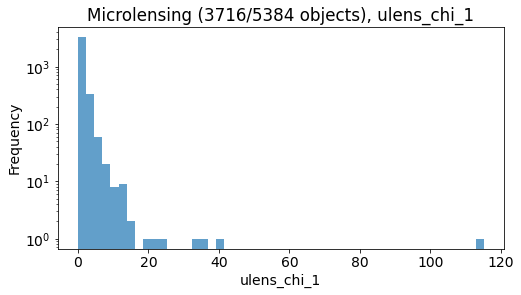

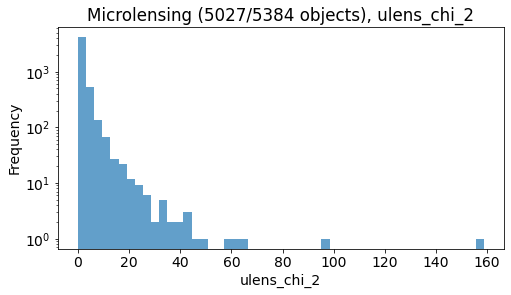

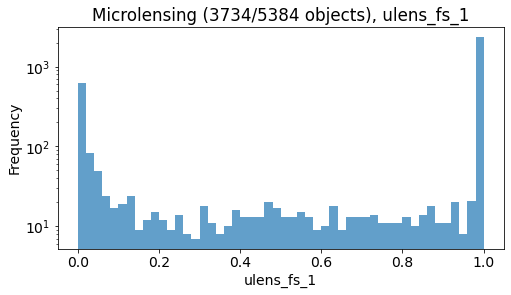

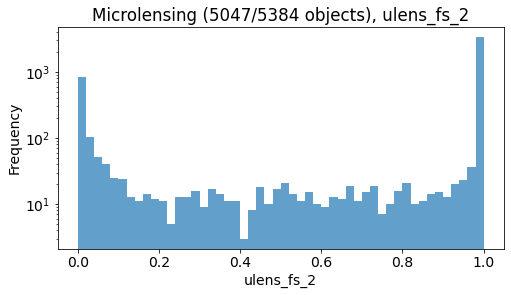

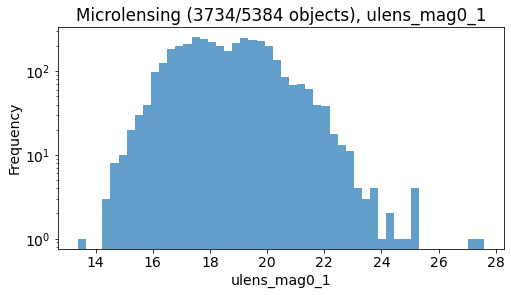

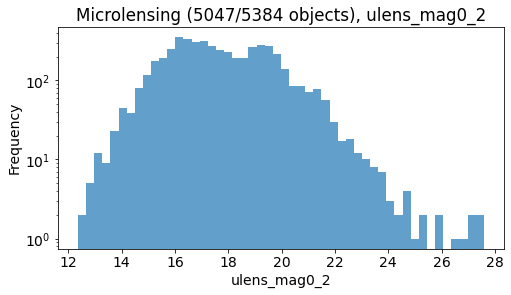

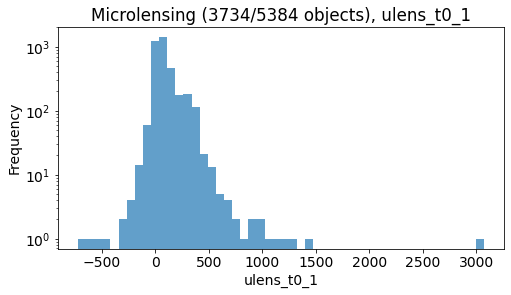

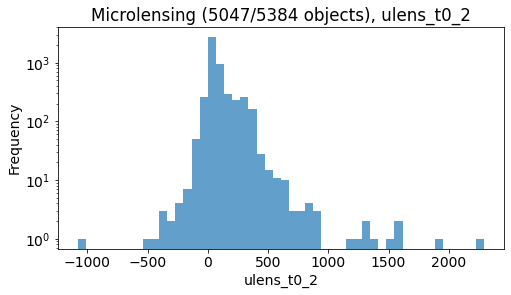

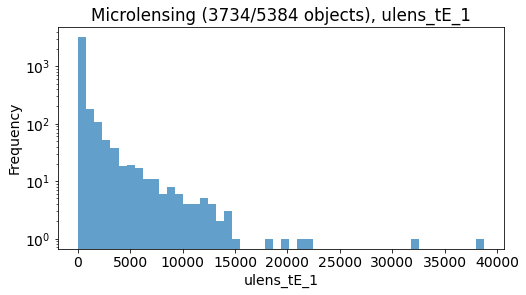

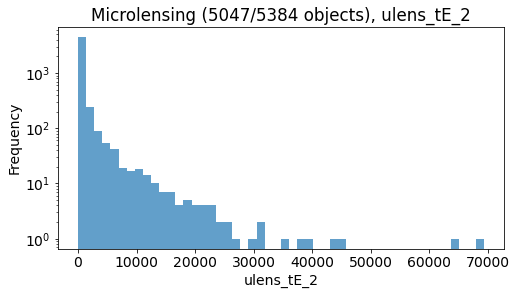

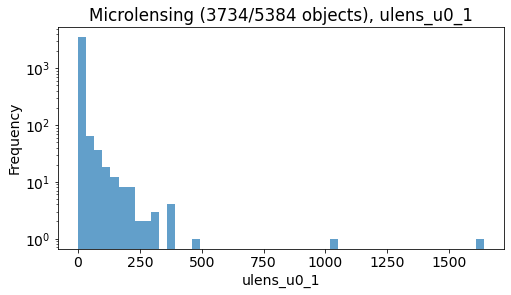

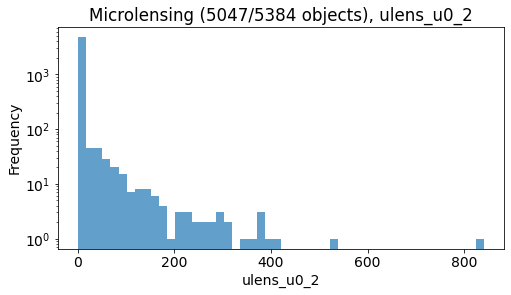

In [58]:
for prop in cols_ulens:
    mask = df_features[prop].notna() & np.isfinite(df_features[prop])
    df_aux = df_features[mask].copy()
    
    title = cl_this + ' (' + str(len(df_aux)) + '/' \
            + str(len(df_probs_r1_ulens)) + ' objects), ' + prop
    plot_cols_hist(df=df_aux, cols=[prop], bins=50,
                   title=title, fontsize=14)

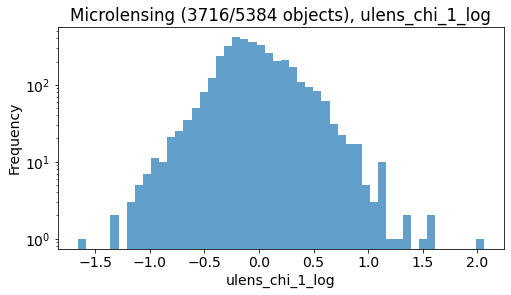

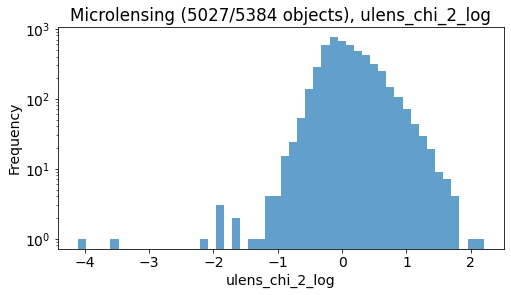

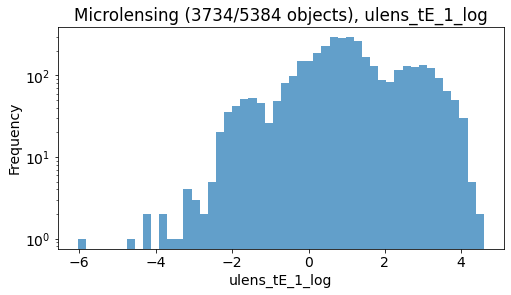

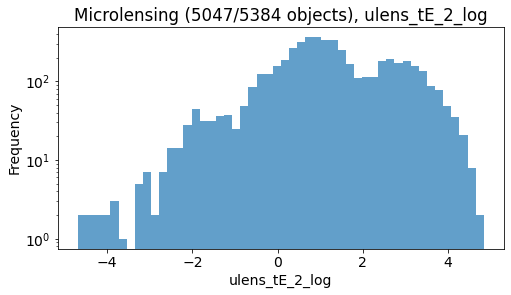

In [59]:
cols = ['ulens_chi_1', 'ulens_chi_2',
        'ulens_tE_1', 'ulens_tE_2']

df_aux = df_features[cols].copy()
for col in df_aux.columns:
    df_aux[col + '_log'] = np.log10(df_aux[col])
df_aux.drop(columns=cols, inplace=True)

for prop in df_aux.columns:
    mask = df_aux[prop].notna() & np.isfinite(df_aux[prop])
    df_aux2 = df_aux[mask].copy()
    
    title = cl_this + ' (' + str(len(df_aux2)) + '/' \
            + str(len(df_probs_r1_ulens)) + ' objects), ' + prop
    plot_cols_hist(df=df_aux2, cols=[prop], bins=50,
                   title=title, fontsize=14)

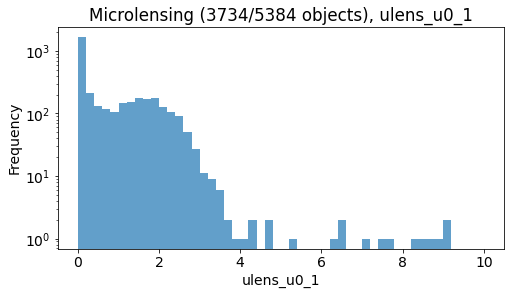

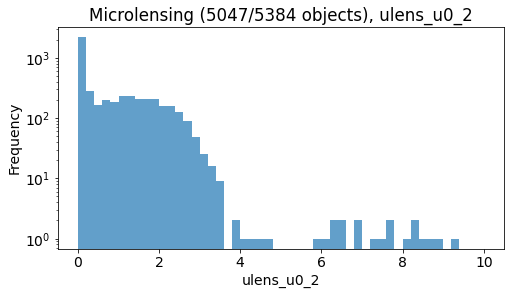

In [60]:
cols = ['ulens_u0_1', 'ulens_u0_2']

for prop in cols:
    mask = df_features[prop].notna() & np.isfinite(df_features[prop])
    df_aux = df_features[mask].copy()
    
    title = cl_this + ' (' + str(len(df_aux)) + '/' \
            + str(len(df_probs_r1_ulens)) + ' objects), ' + prop
    plot_cols_hist(df=df_aux, cols=[prop], bins=50, xlims=[0., 10.],
                   title=title, fontsize=14)

### Use custom cuts in features for refining your sample

In [61]:
mask = (df_features['ulens_u0_1'] < 1) \
        & (df_features['ulens_u0_2'] < 1) \
        & (df_features['ulens_chi_1'] < 1) \
        & (df_features['ulens_chi_2'] < 1) \
        & (df_features['ulens_tE_1'] > 10) \
        & (df_features['ulens_tE_2'] > 10) \
        & (df_features['ulens_tE_1'] < 3e2) \
        & (df_features['ulens_tE_2'] < 3e2)

mask2 = (df_features['ulens_u0_1'] < 1) \
        & df_features['ulens_u0_2'].isna() \
        & (df_features['ulens_chi_1'] < 1) \
        & df_features['ulens_chi_2'].isna() \
        & (df_features['ulens_tE_1'] > 10) \
        & df_features['ulens_tE_2'].isna() \
        & (df_features['ulens_tE_1'] < 3e2)

mask3 = (df_features['ulens_u0_2'] < 1) \
        & df_features['ulens_u0_1'].isna() \
        & (df_features['ulens_chi_2'] < 1) \
        & df_features['ulens_chi_1'].isna() \
        & (df_features['ulens_tE_2'] > 10) \
        & df_features['ulens_tE_1'].isna() \
        & (df_features['ulens_tE_2'] < 3e2)

df_features_sub = df_features[mask | mask2 | mask3].copy()
df_probs_r1_ulens_sub = df_probs_r1_ulens.loc[df_features_sub.index].copy()
df_probs_r1_ulens_sub.sort_values(by='probability', ascending=False, inplace=True)
df_features_sub = df_features_sub.loc[df_probs_r1_ulens_sub.index].copy()
print(str(len(df_features_sub)) + '/' \
      + str(len(df_probs_r1_ulens)) + ' objects')
print_link_ztf(index=df_probs_r1_ulens_sub.index[0:200], classifier='stamp_classifier')
display(df_probs_r1_ulens_sub)
display(df_features_sub[cols_ulens])

206/5384 objects


,class_name,probability,ranking
oid,,,
ZTF25acmyfzn,Microlensing,0.465080,1
ZTF25abccrvf,Microlensing,0.423440,1
ZTF25aavdmlh,Microlensing,0.419328,1
ZTF20abbxgtj,Microlensing,0.410800,1
ZTF26aaqorts,Microlensing,0.397772,1
...,...,...,...
ZTF18admepxf,Microlensing,0.141288,1
ZTF26aamjrxo,Microlensing,0.137592,1
ZTF26aawbkpe,Microlensing,0.133152,1


fname,ulens_chi_1,ulens_chi_2,ulens_fs_1,ulens_fs_2,ulens_mag0_1,ulens_mag0_2,ulens_t0_1,ulens_t0_2,ulens_tE_1,ulens_tE_2,ulens_u0_1,ulens_u0_2
oid,,,,,,,,,,,,
ZTF25acmyfzn,0.704158,0.780594,0.999996,0.999999,21.014147,18.664636,139.241365,36.957619,224.516244,62.880187,0.494944,7.184734e-01
ZTF25abccrvf,0.501802,0.833328,1.000000,0.938045,19.773781,17.721201,56.096881,55.172704,23.949737,25.778649,0.318485,3.782410e-05
ZTF25aavdmlh,0.667112,0.796565,0.087710,0.034149,17.684349,16.706894,68.876293,67.772412,113.308479,253.375849,0.350660,1.710319e-01
ZTF20abbxgtj,NaN,0.615719,NaN,1.000000,NaN,21.156281,NaN,14.135421,NaN,143.632088,NaN,1.304992e-01
ZTF26aaqorts,NaN,0.143684,NaN,0.963585,NaN,16.893005,NaN,-143.902364,NaN,71.496983,NaN,6.451334e-07
...,...,...,...,...,...,...,...,...,...,...,...,...
ZTF18admepxf,NaN,0.862722,NaN,0.999999,NaN,21.045568,NaN,0.238288,NaN,272.258918,NaN,4.165490e-02
ZTF26aamjrxo,NaN,0.714056,NaN,1.000000,NaN,14.948100,NaN,-26.948653,NaN,40.997930,NaN,7.481252e-01
ZTF26aawbkpe,0.642625,0.259290,1.000000,1.000000,20.598578,19.418071,25.453397,74.339331,23.295866,126.653331,0.420608,5.333836e-01


#### Display light curves for the 20 highest probability objects, along with their microlensing model fits

ZTF25acmyfzn


9 detections
61 forced photometry epochs
ZTF25abccrvf


21 detections
60 forced photometry epochs
ZTF25aavdmlh


110 detections
206 forced photometry epochs
ZTF20abbxgtj


11 detections
26 forced photometry epochs
ZTF26aaqorts


...

41 detections
59 forced photometry epochs
ZTF20abehbew


61 detections
152 forced photometry epochs
ZTF26aaumrgp


11 detections
31 forced photometry epochs
ZTF20abfbdpx


9 detections
22 forced photometry epochs
ZTF25aboznoe


9 detections
34 forced photometry epochs


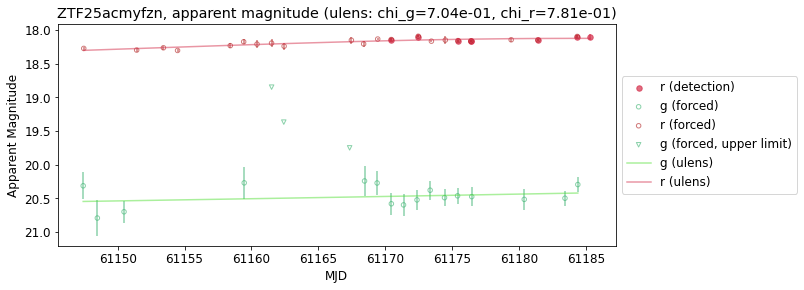

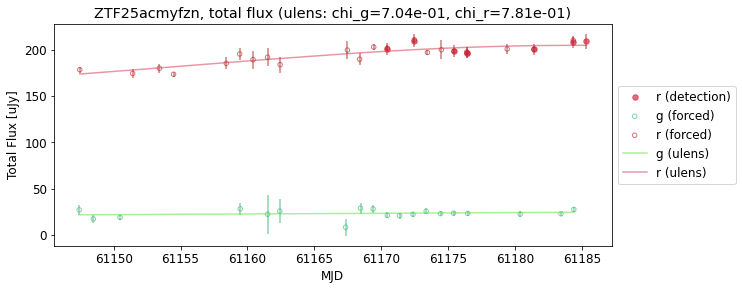

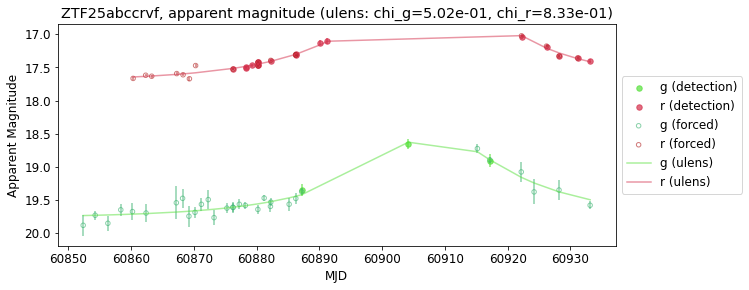

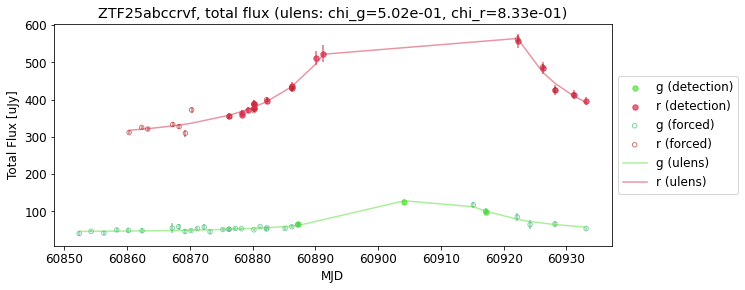

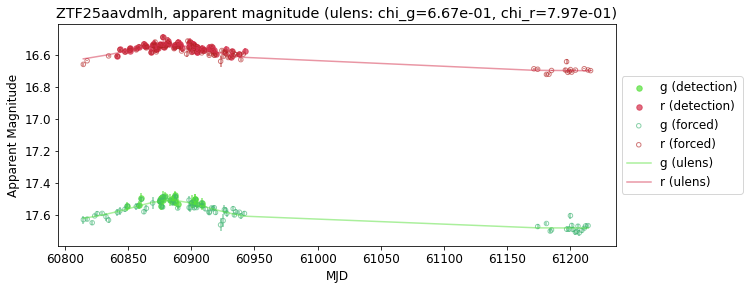

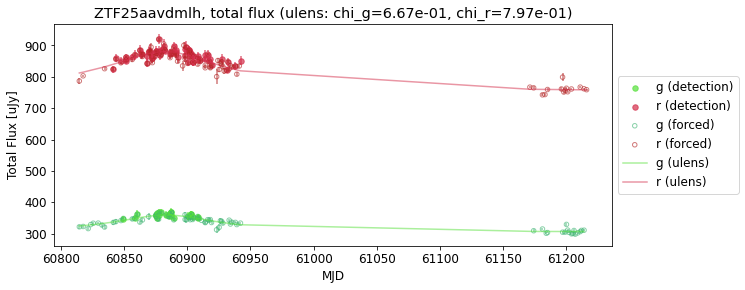

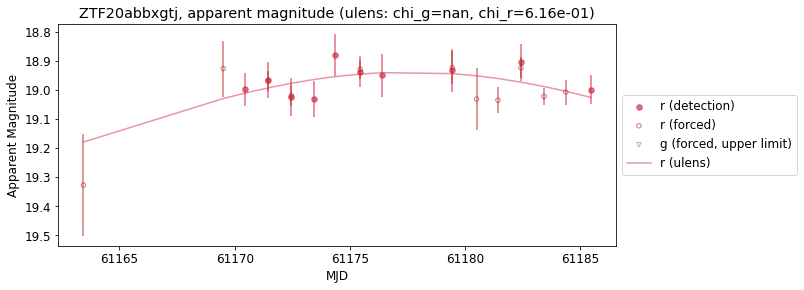

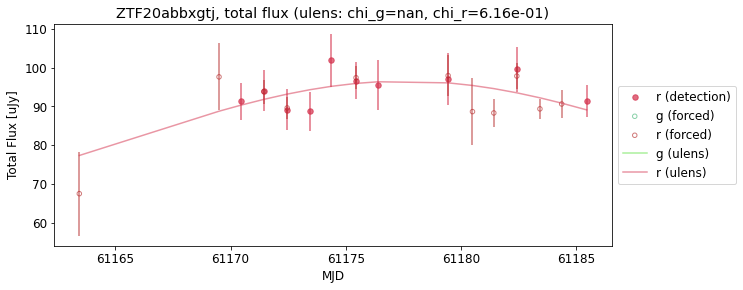

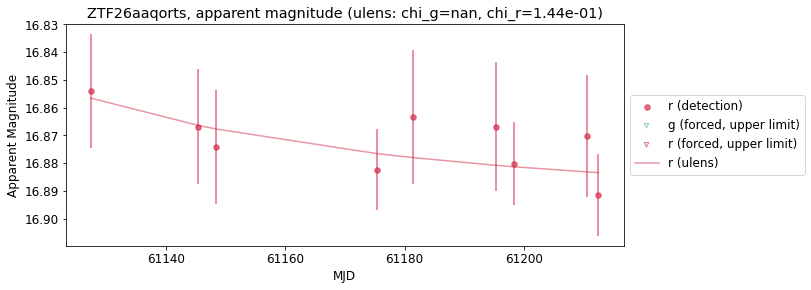

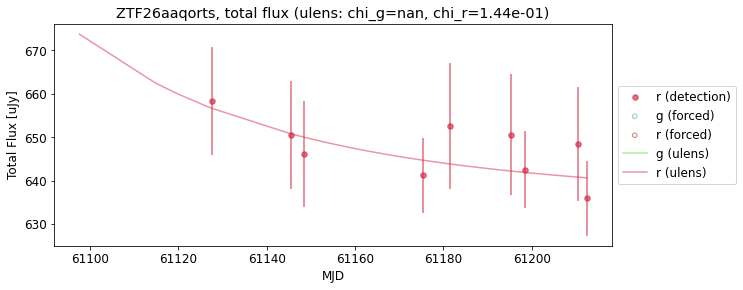

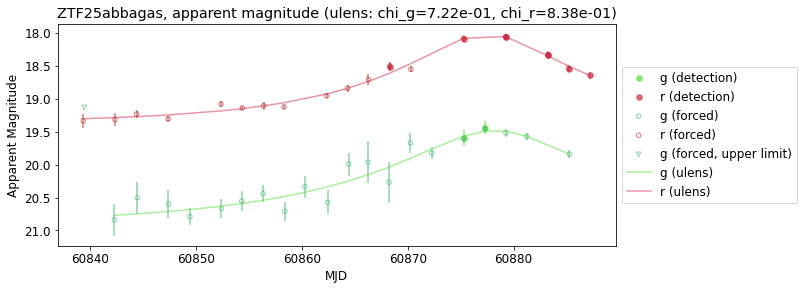

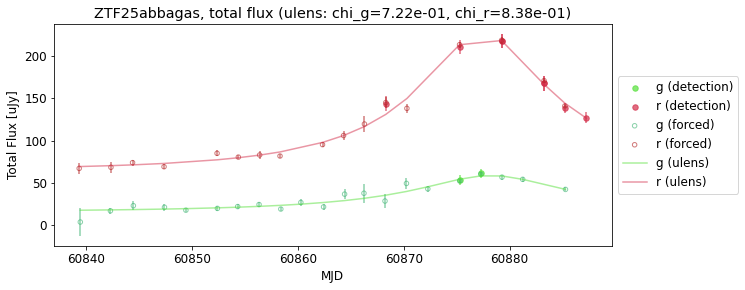

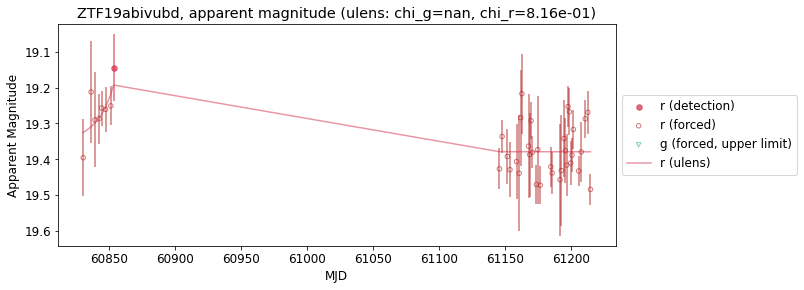

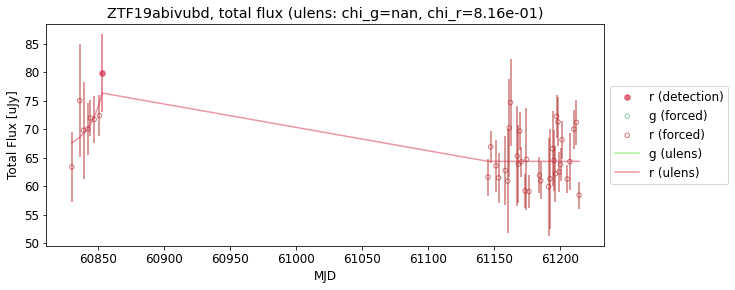

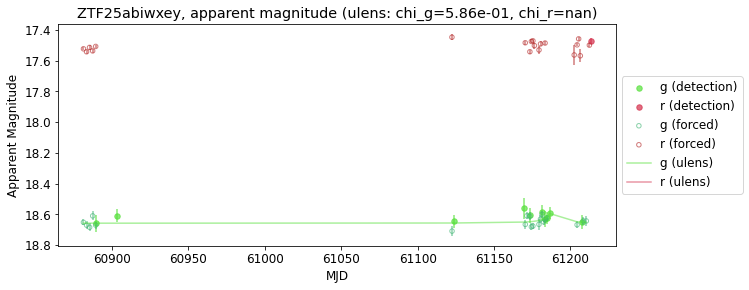

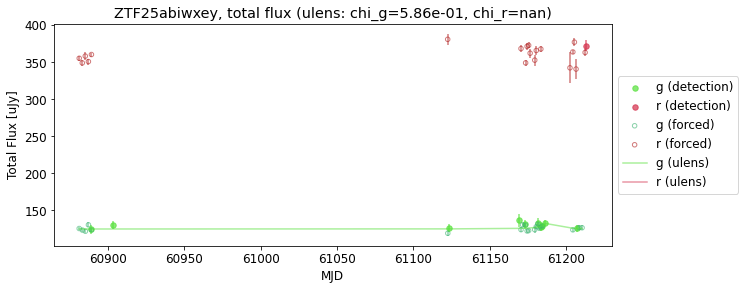

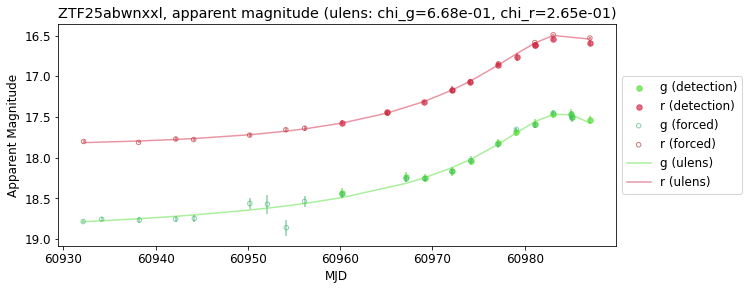

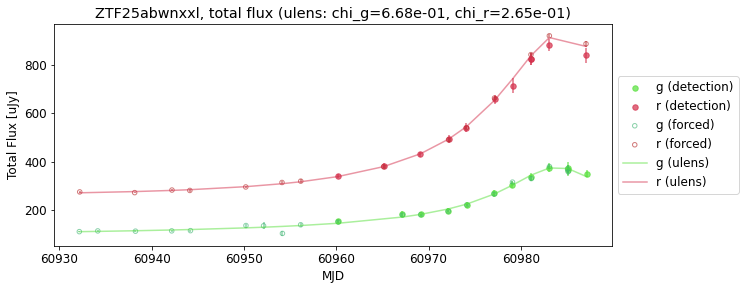

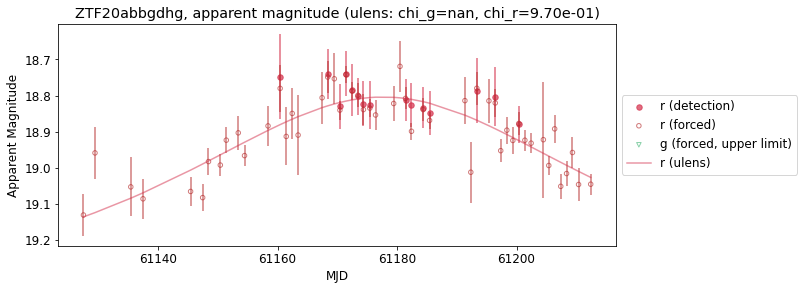

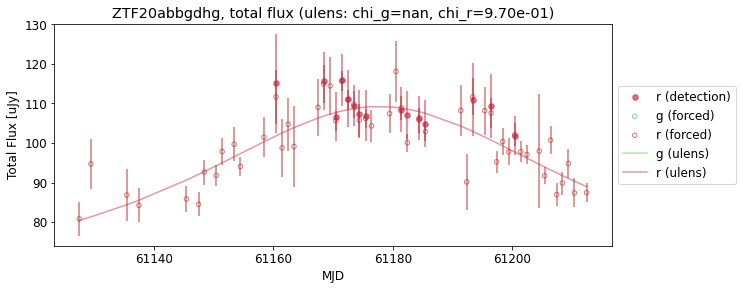

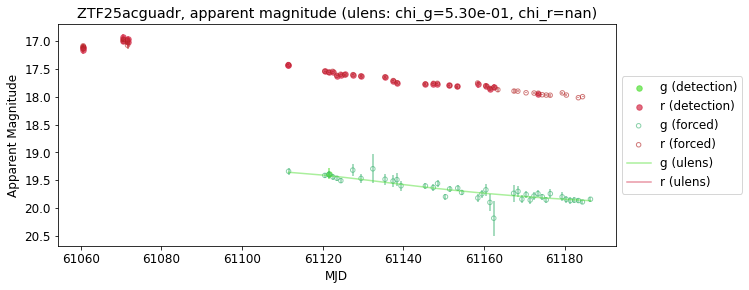

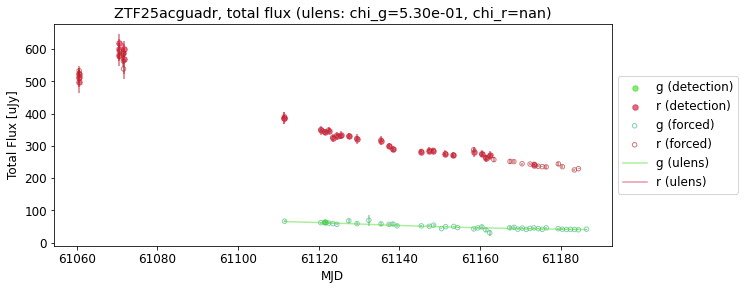

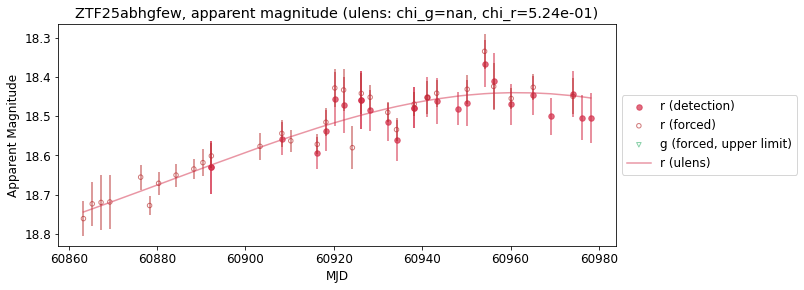

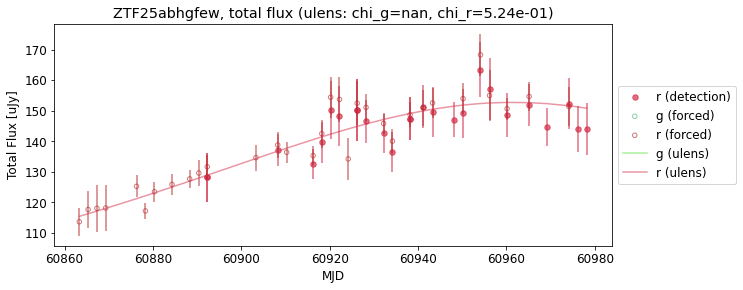

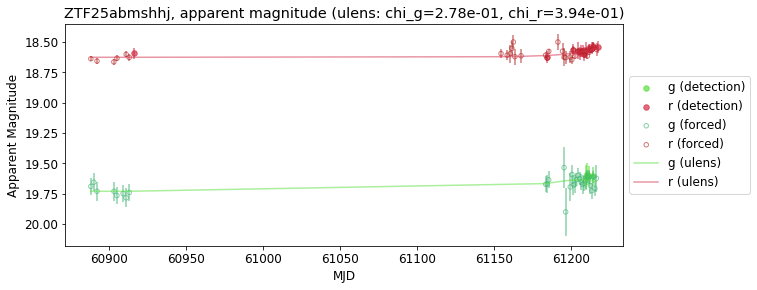

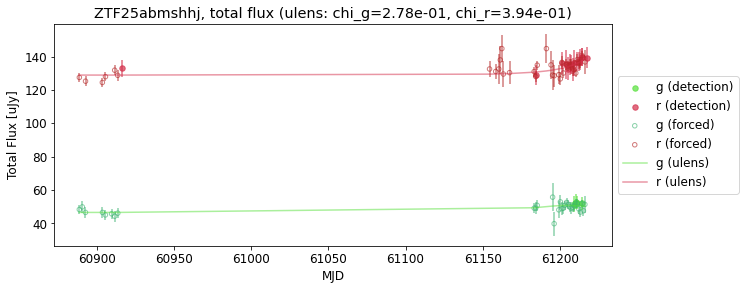

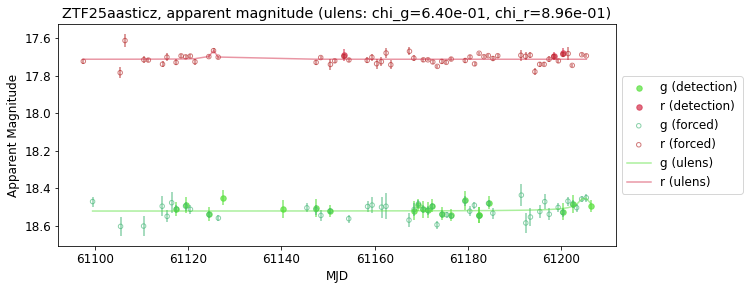

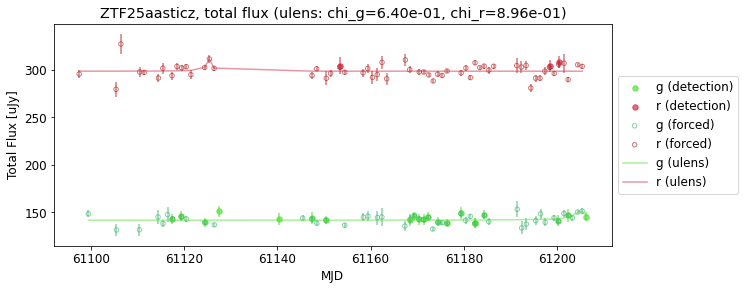

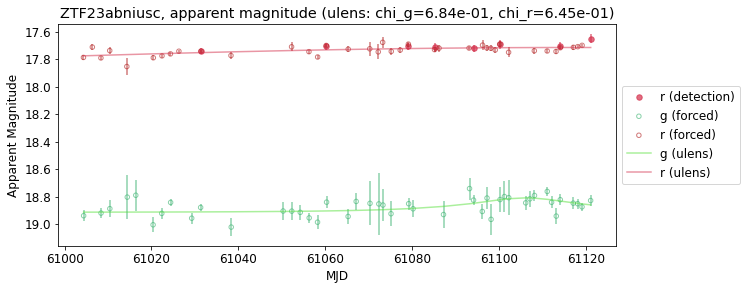

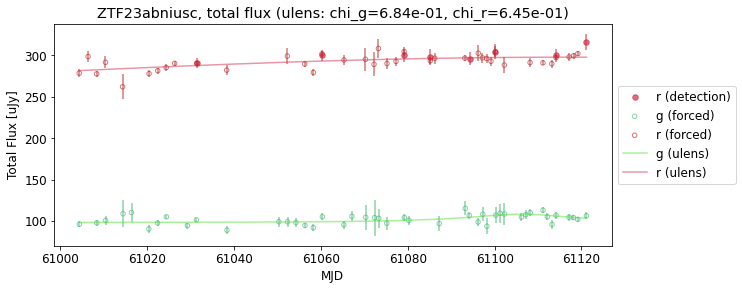

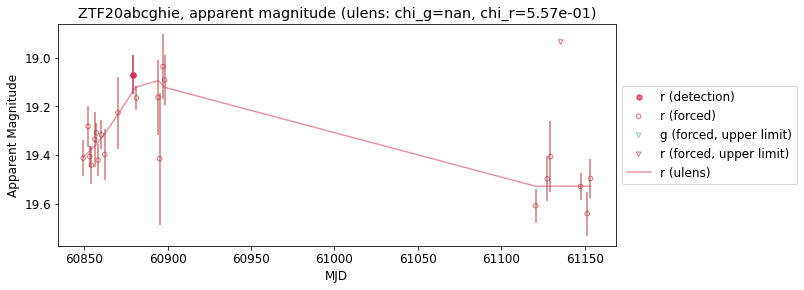

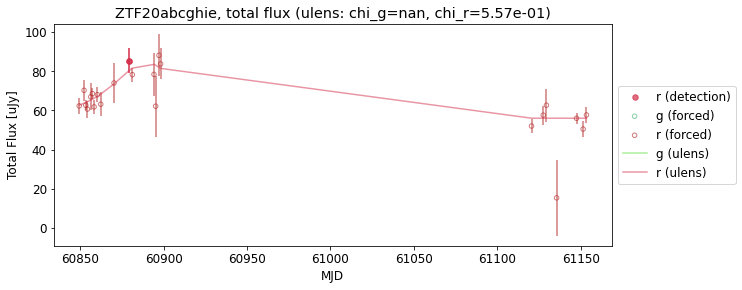

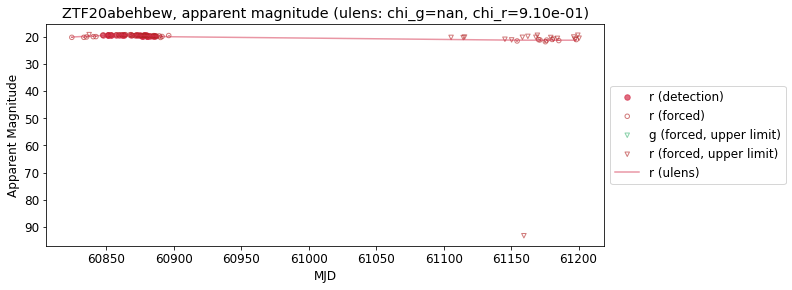

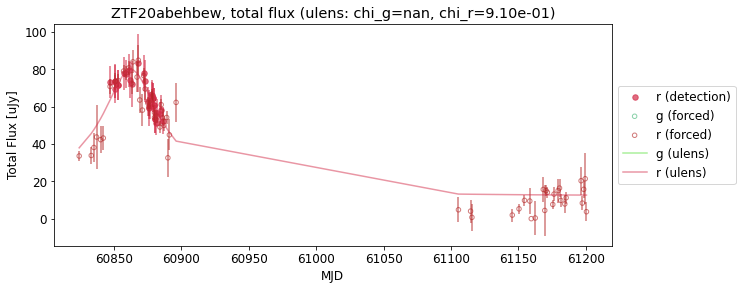

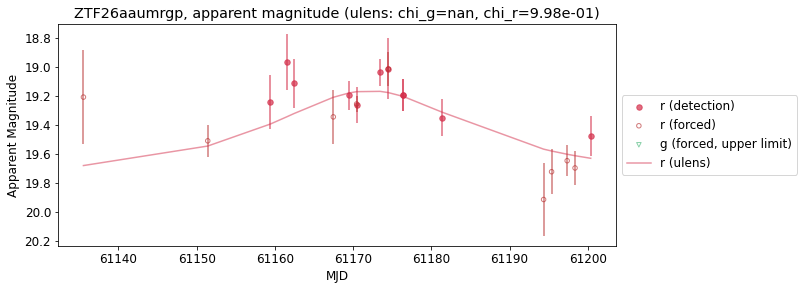

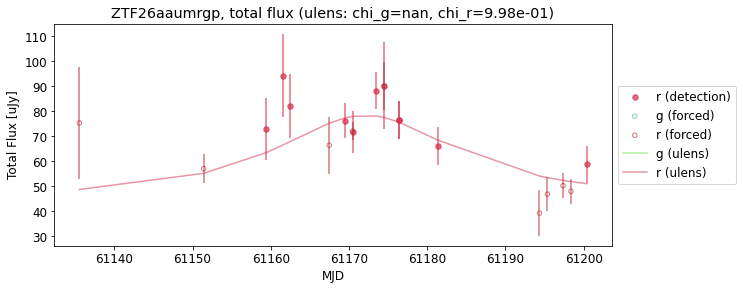

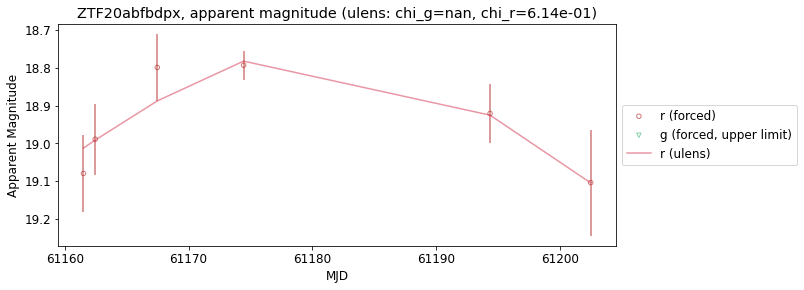

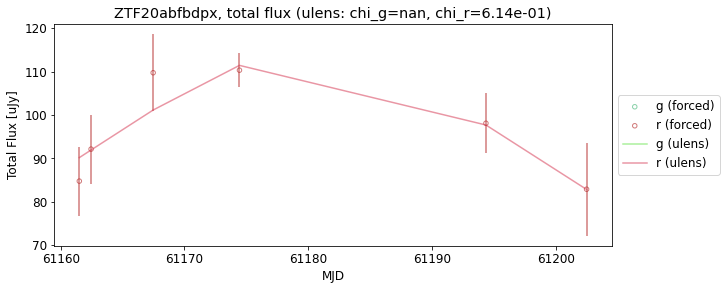

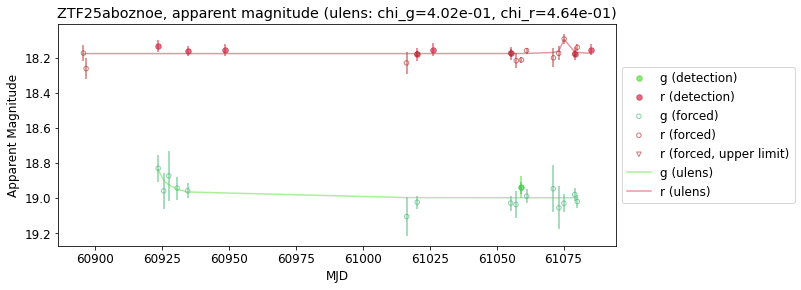

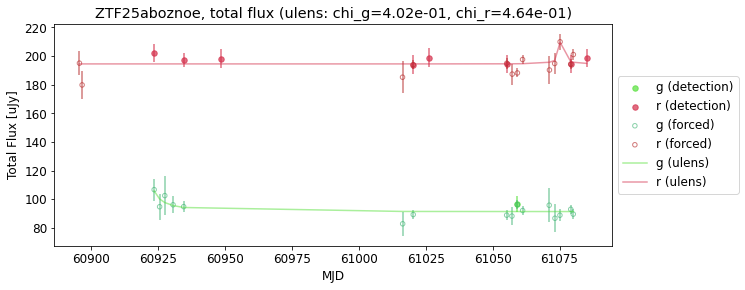

In [62]:
brightness_types = [
    'apparent magnitude',
    'total flux',
    #'difference magnitude',
    #'difference flux',
]

#oids = df_probs_r1_ulens_sub.index
oids = df_probs_r1_ulens_sub.index[0:20]

for oid in oids:
    plot_lc_oid(
        oid=oid,
        #show_params=True,
        #show_epochs=True,
        features=df_features,
        brightness_types=brightness_types,
    )

#### Query ranking=1 probabilities in LC_classifier_ATAT_forced_phot(beta) for recent objects (this classifier is currently in a beta stage, use with caution!)

In [63]:
i = 1
clf_name_beta = classifier_names[i]
clf_version_beta = classifier_versions[i]

In [64]:
print(clf_name_beta, clf_version_beta)

# Loop of queries
df_probs_r1_ulens_beta = query_probs_r1(chunk_size=10000,
                                        oids=df_recent.index,
                                        clf_name=clf_name_beta,
                                        clf_version=clf_version_beta,
                                        cl=cl_this)
df_probs_r1_ulens_beta.set_index('oid', inplace=True)
display(df_probs_r1_ulens_beta)

LC_classifier_ATAT_forced_phot(beta) 1.0.0
11 chunks
Chunk 0
Chunk 1
Chunk 2
Chunk 3
Chunk 4
Chunk 5
Chunk 6
Chunk 7
Chunk 8
Chunk 9
Chunk 10


,class_name,probability,ranking
oid,,,
ZTF26aasqapt,Microlensing,0.865476,1
ZTF25abzoxxm,Microlensing,0.435398,1
ZTF25aavrjen,Microlensing,0.909207,1
ZTF20abjsnrm,Microlensing,0.548507,1
ZTF25abdgumm,Microlensing,0.758430,1
...,...,...,...
ZTF26abacdap,Microlensing,0.285127,1
ZTF20abfmvos,Microlensing,0.689230,1
ZTF26aatugps,Microlensing,0.431750,1


In [65]:
df_probs_r1_ulens_beta.sort_values(by='probability',
                                   ascending=False,
                                   inplace=True)

Show an ALeRCE Explorer link for these objects, sort by probability

In [66]:
print(clf_name_beta, clf_version_beta, cl_this)
print(str(len(df_probs_r1_ulens_beta)) + ' rows')

if len(df_probs_r1_ulens_beta) > 0:
    print_link_ztf(index=df_probs_r1_ulens_beta.iloc[0:200].index, classifier='stamp_classifier')
    display(df_probs_r1_ulens_beta)#.iloc[0:10])

LC_classifier_ATAT_forced_phot(beta) 1.0.0 Microlensing
209 rows


,class_name,probability,ranking
oid,,,
ZTF25abccrvf,Microlensing,0.999987,1
ZTF25abbagas,Microlensing,0.999920,1
ZTF26abckjvu,Microlensing,0.999917,1
ZTF26aatcnyh,Microlensing,0.999846,1
ZTF25acgugbw,Microlensing,0.999782,1
...,...,...,...
ZTF26aajqgvw,Microlensing,0.272970,1
ZTF25abzpeav,Microlensing,0.248752,1
ZTF25aaupqox,Microlensing,0.231980,1


#### Show distribution of probabilities

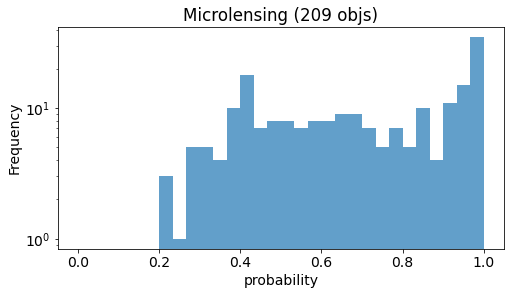

In [67]:
prop = 'probability'
title = cl_this + ' (' + str(len(df_probs_r1_ulens_beta)) + ' objs)'
plot_cols_hist(df=df_probs_r1_ulens_beta, cols=[prop], bins=30, xlims=[0., 1.],
               title=title, fontsize=14)